# Lab 2 — From Raw Data to ML-Ready Data
## Telco Customer Churn — Data Cleaning & Exploratory Data Analysis

**Course:** Machine Learning Lab — BS Computer Science, 5th Semester
**Author:** Tahzeeb Khan
**Dataset:** Telco Customer Churn (Kaggle), 7,043 customer records

---

**Scope note.** This lab stops at the point where the data becomes ML-ready. No model is
trained, no train/test split is made, and no categorical variable is encoded here — those
belong to Lab 3.

In [1]:
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (8, 4.5)
plt.rcParams["figure.dpi"] = 100

pd.set_option("display.max_columns", 50)
pd.set_option("display.width", 120)

print("pandas     :", pd.__version__)
print("numpy      :", np.__version__)

pandas     : 3.0.5
numpy      : 2.5.3


In [2]:
# The file carries a .xls extension but is actually plain CSV text (its first bytes are
# the header line "customerID,gender,..."), so read_csv is correct here and read_excel
# would fail. Resolve the path relative to the notebook so it works from either the
# "Lab 2" folder or the repository root.
FILENAME = "WA_Fn-UseC_-Telco-Customer-Churn.xls"
DATA_PATH = Path.cwd() / FILENAME
if not DATA_PATH.exists():
    DATA_PATH = Path.cwd() / "Lab 2" / FILENAME

df = pd.read_csv(DATA_PATH)
print("Loaded:", DATA_PATH.name)
print("Shape :", df.shape)

Loaded: WA_Fn-UseC_-Telco-Customer-Churn.xls
Shape : (7043, 21)


---
# Part 1 — The Business Problem

Every ML project starts with a business question, not a dataset. Before writing any code,
what does the company actually want to know, and what does a single row represent?

### 1.1 — The business problem and the likely target variable

> **DRAFT — rewrite in your own words before submitting.**

A telecoms company is losing subscribers to competitors and currently only finds out after
a customer has already left, when nothing can be done. The business problem is therefore to
work out *which* customers are at risk while they are still subscribers, so retention effort
can be aimed at them rather than sprayed across the whole base. As a data problem this is
binary classification, and the target variable is **`Churn`**, which records Yes/No for
whether each customer left. One row is one customer account, not one month and not one
transaction, so everything in the row has to be read as that customer's current state.

### 1.2 — Five expected-useful predictors, and two expected to be useless

> **DRAFT — rewrite in your own words before submitting.**

Written before looking at any relationship in the data, so several of these are testable
guesses rather than conclusions.

**Five I expect to be useful**

| Column | Why I expect it to matter |
|---|---|
| `Contract` | A month-to-month customer can leave at any time; a two-year customer is contractually held. The cost of leaving is different, so the behaviour should be different. |
| `tenure` | Someone who has stayed years has already demonstrated they are not leaving; someone in month one has no such habit yet. |
| `MonthlyCharges` | Price is the usual reason people shop around — a higher bill gives a competitor more room to undercut. |
| `InternetService` | Fibre is the premium, most-competed product, so I expect its customers to be the most actively targeted by rivals. |
| `PaymentMethod` | Automatic payment methods renew silently; manual ones make the customer confront the bill every month. |

**Two I expect to be useless**

| Column | Why I expect it not to matter |
|---|---|
| `customerID` | It is an arbitrary account label that is different for every row. It identifies a customer but describes nothing about them. |
| `gender` | I cannot think of a mechanism by which gender would drive a decision to switch telecoms provider. Part 7.4 tests this rather than leaving it as an assumption. |

**Aside:** the `gender` prediction is checked against the data in Part 7.4 and holds; the
`customerID` prediction is revisited in Part 9.

### 1.3 — Two questions I want this data to answer about churned customers

> **DRAFT — rewrite in your own words before submitting.**

1. **Is churn concentrated in a customer's early life, or does it happen steadily throughout?**
   If it is concentrated early, retention effort belongs in onboarding rather than in
   win-back campaigns, which is a completely different intervention.

2. **Do customers leave because of what they pay, or because of what they are tied into?**
   `MonthlyCharges` and `Contract` could both plausibly drive churn, and the answer decides
   whether the company should compete on price or on contract terms.

---
# Part 2 — Exploring the Dataset Structure

Before cleaning or analysing anything, get an accurate picture of the dataset's shape and
contents. Running a command is not the same as understanding its output.

In [3]:
print("Shape (rows, columns):", df.shape)
print()
print("Columns:")
for i, c in enumerate(df.columns, 1):
    print(f"  {i:2d}. {c}")

Shape (rows, columns): (7043, 21)

Columns:
   1. customerID
   2. gender
   3. SeniorCitizen
   4. Partner
   5. Dependents
   6. tenure
   7. PhoneService
   8. MultipleLines
   9. InternetService
  10. OnlineSecurity
  11. OnlineBackup
  12. DeviceProtection
  13. TechSupport
  14. StreamingTV
  15. StreamingMovies
  16. Contract
  17. PaperlessBilling
  18. PaymentMethod
  19. MonthlyCharges
  20. TotalCharges
  21. Churn


In [4]:
df.dtypes

customerID              str
gender                  str
SeniorCitizen         int64
Partner                 str
Dependents              str
tenure                int64
PhoneService            str
MultipleLines           str
InternetService         str
OnlineSecurity          str
OnlineBackup            str
DeviceProtection        str
TechSupport             str
StreamingTV             str
StreamingMovies         str
Contract                str
PaperlessBilling        str
PaymentMethod           str
MonthlyCharges      float64
TotalCharges            str
Churn                   str
dtype: object

In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   str    
 1   gender            7043 non-null   str    
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   str    
 4   Dependents        7043 non-null   str    
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   str    
 7   MultipleLines     7043 non-null   str    
 8   InternetService   7043 non-null   str    
 9   OnlineSecurity    7043 non-null   str    
 10  OnlineBackup      7043 non-null   str    
 11  DeviceProtection  7043 non-null   str    
 12  TechSupport       7043 non-null   str    
 13  StreamingTV       7043 non-null   str    
 14  StreamingMovies   7043 non-null   str    
 15  Contract          7043 non-null   str    
 16  PaperlessBilling  7043 non-null   str    
 17  Paymen

In [6]:
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [7]:
df.sample(5, random_state=42)

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
185,1024-GUALD,Female,0,Yes,No,1,No,No phone service,DSL,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,24.80,24.8,Yes
2715,0484-JPBRU,Male,0,No,No,41,Yes,Yes,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Month-to-month,Yes,Bank transfer (automatic),25.25,996.45,No
3825,3620-EHIMZ,Female,0,Yes,Yes,52,Yes,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,19.35,1031.7,No
1807,6910-HADCM,Female,0,No,No,1,Yes,No,Fiber optic,No,No,Yes,No,No,No,Month-to-month,No,Electronic check,76.35,76.35,Yes
132,8587-XYZSF,Male,0,No,No,67,Yes,No,DSL,No,No,No,Yes,No,No,Two year,No,Bank transfer (automatic),50.55,3260.1,No


In [8]:
# Mechanical split by dtype -- this is what pandas thinks, not necessarily what is true.
numerical_cols = df.select_dtypes(include="number").columns.tolist()
categorical_cols = df.select_dtypes(include="str").columns.tolist()

print(f"NUMERICAL by dtype ({len(numerical_cols)}):")
for c in numerical_cols:
    print("   -", c)
print()
print(f"CATEGORICAL by dtype ({len(categorical_cols)}):")
for c in categorical_cols:
    print("   -", c)
print()
print("Total accounted for:", len(numerical_cols) + len(categorical_cols), "of", df.shape[1])

NUMERICAL by dtype (3):
   - SeniorCitizen
   - tenure
   - MonthlyCharges

CATEGORICAL by dtype (18):
   - customerID
   - gender
   - Partner
   - Dependents
   - PhoneService
   - MultipleLines
   - InternetService
   - OnlineSecurity
   - OnlineBackup
   - DeviceProtection
   - TechSupport
   - StreamingTV
   - StreamingMovies
   - Contract
   - PaperlessBilling
   - PaymentMethod
   - TotalCharges
   - Churn

Total accounted for: 21 of 21


In [9]:
# How many distinct values does each column actually hold? A numeric-typed column with
# only 2 distinct values is a strong hint that its dtype is misleading.
summary = pd.DataFrame({
    "dtype": df.dtypes.astype(str),
    "n_unique": df.nunique(),
    "example_values": [df[c].unique()[:4] for c in df.columns],
})
summary

,dtype,n_unique,example_values
customerID,str,7043,"[7590-VHVEG, 5575-GNVDE, 3668-QPYBK, 7795-CFOCW]"
gender,str,2,"[Female, Male]"
SeniorCitizen,int64,2,"[0, 1]"
Partner,str,2,"[Yes, No]"
Dependents,str,2,"[No, Yes]"
tenure,int64,73,"[1, 34, 2, 45]"
PhoneService,str,2,"[No, Yes]"
MultipleLines,str,3,"[No phone service, No, Yes]"
InternetService,str,3,"[DSL, Fiber optic, No]"
OnlineSecurity,str,3,"[No, Yes, No internet service]"


> **DRAFT — rewrite in your own words before submitting.**

**Scope.** 7,043 customers and 21 columns. Those 21 are not 21 predictors: one is an
identifier (`customerID`) and one is the target (`Churn`), which leaves **19 usable
features**.

**Identifier.** `customerID` has 7,043 distinct values across 7,043 rows — one per row. A
column that never repeats cannot describe a group of customers, so it can only label them.

**Two dtypes that do not match what the column means.**

- **`SeniorCitizen`** is stored as `int64` and so pandas lists it as numerical, but the
  unique-value table shows it holds exactly 2 distinct values (`0` and `1`). It is a yes/no
  flag wearing a number's dtype. Left alone, pandas would happily compute its mean or drop
  it into a correlation matrix, where a "mean senior-citizen-ness of 0.16" means nothing.
- **`TotalCharges`** is stored as text (`str`) while `MonthlyCharges` is `float64`. Both are
  money, so there is no honest reason for them to differ. Something inside `TotalCharges`
  is preventing pandas from parsing it as a number — chased down in Part 3.3.

**So the mechanical split is wrong in both directions.** By dtype, pandas reports 3
numerical and 18 categorical columns. Correcting both errors, the truth is 3 genuinely
numerical features (`tenure`, `MonthlyCharges`, `TotalCharges`), 17 genuinely categorical
columns including the target, and 1 identifier.

*(Note: this notebook runs on pandas 3.x, which reports text columns as `str`. Older pandas
versions display the same columns as `object` — the meaning is identical.)*

### 2.3 — Unique values of three categorical columns

In [10]:
for col in ["MultipleLines", "OnlineSecurity", "PaymentMethod"]:
    print(f"--- {col} ---")
    print("unique   :", df[col].unique().tolist())
    print(df[col].value_counts())
    print()

--- MultipleLines ---
unique   : ['No phone service', 'No', 'Yes']
MultipleLines
No                  3390
Yes                 2971
No phone service     682
Name: count, dtype: int64

--- OnlineSecurity ---
unique   : ['No', 'Yes', 'No internet service']
OnlineSecurity
No                     3498
Yes                    2019
No internet service    1526
Name: count, dtype: int64

--- PaymentMethod ---
unique   : ['Electronic check', 'Mailed check', 'Bank transfer (automatic)', 'Credit card (automatic)']
PaymentMethod
Electronic check             2365
Mailed check                 1612
Bank transfer (automatic)    1544
Credit card (automatic)      1522
Name: count, dtype: int64



In [11]:
# Is 'No phone service' / 'No internet service' a real third category, or just a sentinel
# that restates another column? Test it directly rather than assuming.
print("PhoneService == 'No'                       :", (df["PhoneService"] == "No").sum())
print("MultipleLines == 'No phone service'        :", (df["MultipleLines"] == "No phone service").sum())
print("  -> identical rows?                       :",
      (df["PhoneService"].eq("No") == df["MultipleLines"].eq("No phone service")).all())
print()
print("InternetService == 'No'                    :", (df["InternetService"] == "No").sum())
internet_cols = ["OnlineSecurity", "OnlineBackup", "DeviceProtection",
                 "TechSupport", "StreamingTV", "StreamingMovies"]
for c in internet_cols:
    same = (df["InternetService"].eq("No") == df[c].eq("No internet service")).all()
    print(f"  {c:<18} 'No internet service' = {(df[c] == 'No internet service').sum():>5}  identical rows? {same}")

PhoneService == 'No'                       : 682
MultipleLines == 'No phone service'        : 682
  -> identical rows?                       : True

InternetService == 'No'                    : 1526
  OnlineSecurity     'No internet service' =  1526  identical rows? True
  OnlineBackup       'No internet service' =  1526  identical rows? True
  DeviceProtection   'No internet service' =  1526  identical rows? True
  TechSupport        'No internet service' =  1526  identical rows? True
  StreamingTV        'No internet service' =  1526  identical rows? True
  StreamingMovies    'No internet service' =  1526  identical rows? True


> **DRAFT — rewrite in your own words before submitting.**

The three columns are internally consistent — no stray casing, no `"yes"`/`"Yes"` mixture,
no misspelled category. `PaymentMethod` splits into four fairly even groups, the largest
being Electronic check at 2,365.

**But `MultipleLines` and `OnlineSecurity` contain a category that is not really a
category.** Both are described as three-level columns, and the third level is a sentinel:

- `MultipleLines` = `'No phone service'` occurs 682 times, and `PhoneService` = `'No'` also
  occurs 682 times. The check confirms these are *the same rows*, not merely the same count.
- `'No internet service'` occurs 1,526 times in each of `OnlineSecurity`, `OnlineBackup`,
  `DeviceProtection`, `TechSupport`, `StreamingTV` and `StreamingMovies` — and in all six
  cases those are exactly the rows where `InternetService` = `'No'`.

So seven columns carry a third value that restates information already held in
`PhoneService` / `InternetService`. Logically each is a two-level question ("do they have
this add-on?") plus a structural fact ("the add-on cannot apply to them"). This is not
dirty data — nothing is wrong or inconsistent — but it is **redundant encoding**, and it
matters for Lab 3: one-hot encoding these as-is would create seven dummy columns that are
perfectly predictable from `InternetService`. I have left them untouched here, because
collapsing them is a feature-engineering decision and this lab stops before that.

---
# Part 3 — Investigating Data Quality

A dataset can look clean at a glance and still hide serious problems. The point of this
section is to actively search rather than assume.

### 3.1 — Missing values, as a count and as a percentage

In [12]:
missing = pd.DataFrame({
    "missing_count": df.isnull().sum(),
    "missing_percent": (df.isnull().mean() * 100).round(2),
})
missing

,missing_count,missing_percent
customerID,0,0.0
gender,0,0.0
SeniorCitizen,0,0.0
Partner,0,0.0
Dependents,0,0.0
tenure,0,0.0
PhoneService,0,0.0
MultipleLines,0,0.0
InternetService,0,0.0
OnlineSecurity,0,0.0


In [13]:
print("Total missing cells reported by isnull():", df.isnull().sum().sum())

Total missing cells reported by isnull(): 0


### 3.2 — Duplicate rows vs. duplicate customer IDs (checked separately)

In [14]:
print("Fully duplicated rows      :", df.duplicated().sum())
print("Duplicated customerID values:", df["customerID"].duplicated().sum())
print()
print("Rows in dataset            :", len(df))
print("Distinct customerID values :", df["customerID"].nunique())

Fully duplicated rows      : 0
Duplicated customerID values: 0

Rows in dataset            : 7043
Distinct customerID values : 7043


In [15]:
# A third, sharper check. customerID is unique by construction, so it single-handedly makes
# every row unique -- which means df.duplicated() above could never have returned anything
# else. The honest question is whether any two DIFFERENT customers are identical once the
# identifier is ignored.
feature_cols = [c for c in df.columns if c != "customerID"]
dup_ignoring_id = df.duplicated(subset=feature_cols).sum()
print("Duplicate rows once customerID is ignored:", dup_ignoring_id)
print("Rows involved in such duplicate groups   :",
      df.duplicated(subset=feature_cols, keep=False).sum())

Duplicate rows once customerID is ignored: 22
Rows involved in such duplicate groups   : 42


In [16]:
# Who are they? Look before deciding anything.
collide = df[df.duplicated(subset=feature_cols, keep=False)]
print("tenure values among colliding rows:", sorted(collide["tenure"].unique().tolist()))
print("Contract types                    :", collide["Contract"].unique().tolist())
print()
print("Churn labels within these groups:")
print(collide["Churn"].value_counts())
print()
collide.sort_values(["MonthlyCharges", "customerID"])[
    ["customerID", "gender", "tenure", "InternetService", "MonthlyCharges", "TotalCharges", "Churn"]
].head(12)

tenure values among colliding rows: [1]
Contract types                    : ['Month-to-month']

Churn labels within these groups:
Churn
Yes    24
No     18
Name: count, dtype: int64



,customerID,gender,tenure,InternetService,MonthlyCharges,TotalCharges,Churn
542,2866-IKBTM,Female,1,No,19.55,19.55,No
1491,8605-ITULD,Female,1,No,19.55,19.55,No
6774,0970-QXPXW,Female,1,No,19.65,19.65,No
5170,7721-DVEKZ,Female,1,No,19.65,19.65,No
4817,6654-QGBZZ,Female,1,No,19.90,19.9,No
6706,7878-RTCZG,Female,1,No,19.90,19.9,No
662,3030-ZKIWL,Male,1,No,20.05,20.05,No
3754,7096-UCLNH,Male,1,No,20.05,20.05,No
5736,8749-CLJXC,Male,1,No,20.05,20.05,No
6609,1000-AJSLD,Male,1,No,20.10,20.1,Yes


### 3.3 — Hunting for suspicious, invalid or inconsistently formatted values

`isnull()` reported nothing, but that only proves there are no *pandas-recognised* nulls.
A value can be present as a string and still be meaningless. Two checks follow: whether any
column that should be numeric is stored as text, and whether any text cell is empty or
whitespace-only.

In [17]:
# TotalCharges is money, so it should be numeric. What dtype did pandas actually infer?
print("TotalCharges dtype:", df["TotalCharges"].dtype)
print("MonthlyCharges dtype:", df["MonthlyCharges"].dtype)
print()
print("If TotalCharges is text while MonthlyCharges is float, at least one value in")
print("TotalCharges cannot be parsed as a number. Force the conversion and count failures:")
print()

total_charges_numeric = pd.to_numeric(df["TotalCharges"], errors="coerce")
n_bad = total_charges_numeric.isna().sum()
print("Values that failed to convert to numeric:", n_bad)
print("As a percentage of the dataset          :", round(n_bad / len(df) * 100, 3), "%")

TotalCharges dtype: str
MonthlyCharges dtype: float64

If TotalCharges is text while MonthlyCharges is float, at least one value in
TotalCharges cannot be parsed as a number. Force the conversion and count failures:

Values that failed to convert to numeric: 11
As a percentage of the dataset          : 0.156 %


In [18]:
# What do those unconvertible values actually contain? repr() makes whitespace visible.
bad_mask = total_charges_numeric.isna()
print("Distinct raw values that failed conversion:",
      {repr(v) for v in df.loc[bad_mask, "TotalCharges"]})
print()
df.loc[bad_mask, ["customerID", "tenure", "Contract", "MonthlyCharges", "TotalCharges", "Churn"]]

Distinct raw values that failed conversion: {"' '"}



,customerID,tenure,Contract,MonthlyCharges,TotalCharges,Churn
488,4472-LVYGI,0,Two year,52.55,,No
753,3115-CZMZD,0,Two year,20.25,,No
936,5709-LVOEQ,0,Two year,80.85,,No
1082,4367-NUYAO,0,Two year,25.75,,No
1340,1371-DWPAZ,0,Two year,56.05,,No
3331,7644-OMVMY,0,Two year,19.85,,No
3826,3213-VVOLG,0,Two year,25.35,,No
4380,2520-SGTTA,0,Two year,20.00,,No
5218,2923-ARZLG,0,One year,19.70,,No
6670,4075-WKNIU,0,Two year,73.35,,No


In [19]:
# Are those 11 rows random, or do they share something? Check against tenure.
print("tenure values among the 11 bad rows:")
print(df.loc[bad_mask, "tenure"].value_counts())
print()
print("Rows in the whole dataset with tenure == 0 :", (df["tenure"] == 0).sum())
print("Are the two sets exactly the same rows?    :", bad_mask.equals(df["tenure"] == 0))
print()
print("Churn among those 11 customers:")
print(df.loc[bad_mask, "Churn"].value_counts())

tenure values among the 11 bad rows:
tenure
0    11
Name: count, dtype: int64

Rows in the whole dataset with tenure == 0 : 11
Are the two sets exactly the same rows?    : True

Churn among those 11 customers:
Churn
No    11
Name: count, dtype: int64


In [20]:
# Sweep every text column for empty or whitespace-only cells, so the check is not limited
# to the one column that happened to be obvious.
text_cols = df.select_dtypes(include="str").columns
blank_report = {c: int(df[c].astype(str).str.strip().eq("").sum()) for c in text_cols}
blank_report = {c: n for c, n in blank_report.items() if n > 0}
print("Columns containing blank / whitespace-only cells:", blank_report if blank_report else "none")
print()
padded = {c: int((df[c].astype(str) != df[c].astype(str).str.strip()).sum()) for c in text_cols}
padded = {c: n for c, n in padded.items() if n > 0}
print("Columns with stray leading/trailing whitespace  :", padded if padded else "none")

Columns containing blank / whitespace-only cells: {'TotalCharges': 11}



Columns with stray leading/trailing whitespace  : {'TotalCharges': 11}


> **DRAFT — rewrite in your own words before submitting.**

### Missing values — and why the first answer was misleading

`isnull().sum()` returns **0 for all 21 columns**, and the total number of missing cells is
**0**. Taken at face value this dataset has no missing data at all.

That conclusion is wrong, and the reason is worth stating: `isnull()` only detects values
pandas has already recognised as null. A cell containing the string `" "` is, as far as
pandas is concerned, a perfectly good piece of text. **The missing data here is hidden
inside a text column rather than absent from it**, so it has to be found by a different
route — which is what 3.3 does.

### Duplicates — two genuinely different questions

- Fully duplicated rows: **0**
- Duplicated `customerID` values: **0** (7,043 distinct IDs for 7,043 rows)

These are *not* the same check, and the distinction matters more than it first appears.
Duplicate IDs would mean the same account was recorded twice — an integrity failure.
Duplicate rows would mean two records agree on everything. But because `customerID` is
unique by construction, it single-handedly forces every row to be unique, so
`df.duplicated()` was mathematically incapable of returning anything other than 0. **The
first check was guaranteed to pass and therefore proved nothing.**

Asking the question properly — are any two *different* customers identical once the
identifier is ignored? — gives **22 duplicate rows across 42 involved rows**. Every one of
them has `tenure == 1` and a month-to-month contract. This is not corruption: after a single
month `TotalCharges` necessarily equals `MonthlyCharges`, so the feature space at tenure 1
is coarse enough that unrelated customers genuinely collide. It is acted on in Part 11.

### The suspicious value, and how it was found

I did not find it by scanning the data; I found it by noticing a **contradiction between two
columns that should behave the same way**. `MonthlyCharges` is `float64` but `TotalCharges`
is text, even though both are money. The only way that happens is if some value in
`TotalCharges` cannot be parsed as a number.

Forcing the conversion with `pd.to_numeric(..., errors='coerce')` turned **11 values** into
NaN — 0.156% of the data. Printing them with `repr()` shows the culprit is `' '`, a single
space character, which is invisible in normal output and is exactly why `isnull()` missed it.

Those 11 rows are not random. **All 11 have `tenure == 0`, and they are exactly the 11
tenure-zero rows in the dataset** — the check confirms the two sets are identical, not just
equal in size. All 11 have `Churn == 'No'`. So these are brand-new customers who had not yet
completed a billing cycle when the data was extracted. The blank is not a recording error;
it is the system having nothing to record yet.

A sweep of every text column confirms `TotalCharges` is the *only* column with blank or
whitespace-padded cells, so this problem is contained.

**Which problems need action:** the 11 blanks and the two wrong dtypes do, because they
silently break arithmetic — `TotalCharges` cannot be averaged, plotted or correlated while
it is text. The 22 identifier-free duplicates need a *decision* but not a fix.

---
# Part 4 — Data Cleaning Decisions

Cleaning is a series of justified decisions, not a fixed recipe. Every row in the table
below corresponds to an issue that was actually observed in Part 3 — nothing is cleaned
"just in case", and nothing found in Part 3 is left unaddressed.

> **DRAFT — rewrite in your own words before submitting.**

Each row below corresponds to an issue actually observed in Part 3. The **Reason** column is
the part to rewrite in your own words.

| # | Problem | Decision | Method Used | Reason |
|---|---|---|---|---|
| 1 | `TotalCharges` has 11 cells containing `' '`, invisible to `isnull()` | Convert the column to a real number and let the bad values surface as NaN | `pd.to_numeric(df['TotalCharges'], errors='coerce')` | _(draft)_ The column is money and must support arithmetic. `errors='coerce'` is chosen over `errors='raise'` deliberately: it converts the problem into something countable and inspectable instead of crashing, so the 11 bad values can be examined before anything is decided about them. |
| 2 | Those 11 NaN now need a value | Fill with `0.0` | `df.loc[mask, 'TotalCharges'] = 0.0`, guarded by an `assert` that every such row has `tenure == 0` | _(draft)_ This is the one case where a fill is not a guess. Part 3 proved all 11 rows have `tenure == 0`, and a customer who has been subscribed for zero months has been charged nothing — so 0.0 is the *known* value. Median imputation (1,394.55) was rejected because it would credit thousands of dollars of history to customers who have none, and would corrupt the `tenure`↔`TotalCharges` relationship examined in Part 8. Dropping the 11 rows was rejected because they are valid new customers, and new customers are precisely the group Part 7 shows to be at highest risk. The `assert` is there so that if this notebook is ever re-run on a file where the assumption does not hold, it fails loudly instead of silently filling nonsense. |
| 3 | `TotalCharges` has stray whitespace | Strip whitespace from all 18 text columns | `df[text_cols].apply(lambda s: s.str.strip())` | _(draft)_ Applied before the numeric conversion so `' '` becomes `''` and is handled uniformly with any other blank. Applied across every text column rather than just the one known offender, because ` 'Yes'` and `'Yes'` would otherwise silently become two different categories in any later grouping or encoding. It is a no-op everywhere else, which costs nothing. |
| 4 | `SeniorCitizen` is `int64`, so pandas treats a yes/no flag as a number | Map to `'Yes'`/`'No'` | `df['SeniorCitizen'].map({0: 'No', 1: 'Yes'})` | _(draft)_ Its dtype was inviting meaningless operations — a mean, or a place in the Part 8 correlation matrix. Mapping it to the same `Yes`/`No` vocabulary already used by `Partner`, `Dependents` and `PhoneService` makes the dataset internally consistent and means one encoding rule in Lab 3 covers all four columns. No information is lost; the mapping is reversible. |
| 5 | Duplicates must be ruled out, not assumed absent | Run `drop_duplicates()` even though Part 3 found nothing to drop | `df_clean.drop_duplicates()`, with rows-before/rows-after printed | _(draft)_ Kept as an explicit, logged no-op (0 rows removed) so the notebook records that the check was performed rather than skipped. The related finding — 22 duplicates once `customerID` is ignored — is deliberately handled in Part 11 instead, because it only becomes a real question after the identifier is dropped. |

**Not cleaned, deliberately:** the `'No internet service'` / `'No phone service'` sentinels
from Part 2.3. They are redundant, not wrong, and collapsing them is feature engineering —
out of scope for this lab.

In [21]:
df_clean = df.copy()
print("Starting from a copy of the raw data:", df_clean.shape)

Starting from a copy of the raw data: (7043, 21)


In [22]:
# --- Decision 1: strip stray whitespace from every text column -------------------------
# Applied first, so that the ' ' cells in TotalCharges become '' and are handled uniformly
# with any other blank. Harmless where there is no padding.
text_cols = df_clean.select_dtypes(include="str").columns
df_clean[text_cols] = df_clean[text_cols].apply(lambda s: s.str.strip())
print("Whitespace stripped from", len(text_cols), "text columns.")

Whitespace stripped from 18 text columns.


In [23]:
# --- Decision 2: convert TotalCharges to a true numeric column -------------------------
before_dtype = df_clean["TotalCharges"].dtype
df_clean["TotalCharges"] = pd.to_numeric(df_clean["TotalCharges"], errors="coerce")
n_missing_after_coerce = df_clean["TotalCharges"].isna().sum()

print(f"TotalCharges dtype: {before_dtype}  ->  {df_clean['TotalCharges'].dtype}")
print("Missing values created by the coercion:", n_missing_after_coerce)

TotalCharges dtype: str  ->  float64
Missing values created by the coercion: 11


In [24]:
# --- Decision 3: fill those missing TotalCharges with 0.0 ------------------------------
# Justified only because Part 3 proved every one of these rows has tenure == 0. A customer
# who has been with the company for zero months has not completed a billing cycle, so the
# total amount charged to date is genuinely 0 -- this is a known value, not an estimate.
# Guard the assumption explicitly rather than trusting it.
missing_mask = df_clean["TotalCharges"].isna()
assert (df_clean.loc[missing_mask, "tenure"] == 0).all(), \
    "Fill-with-0 is only valid if every missing TotalCharges has tenure == 0"

df_clean.loc[missing_mask, "TotalCharges"] = 0.0
print("Filled", missing_mask.sum(), "TotalCharges values with 0.0 (all had tenure == 0).")
print("Remaining missing TotalCharges:", df_clean["TotalCharges"].isna().sum())

Filled 11 TotalCharges values with 0.0 (all had tenure == 0).
Remaining missing TotalCharges: 0


In [25]:
# --- Decision 4: give SeniorCitizen a dtype that matches its meaning -------------------
# It is stored as int64 0/1, so pandas treats it as a number and would happily compute its
# mean or place it in a correlation matrix. It is really a yes/no flag, so map it to the
# same Yes/No vocabulary used by Partner, Dependents and PhoneService.
print("Before:", df_clean["SeniorCitizen"].dtype, "| values:", sorted(df_clean["SeniorCitizen"].unique().tolist()))
df_clean["SeniorCitizen"] = df_clean["SeniorCitizen"].map({0: "No", 1: "Yes"})
print("After :", df_clean["SeniorCitizen"].dtype, "| values:", sorted(df_clean["SeniorCitizen"].unique().tolist()))
print()
print(df_clean["SeniorCitizen"].value_counts())

Before: int64 | values: [0, 1]
After : str | values: ['No', 'Yes']

SeniorCitizen
No     5901
Yes    1142
Name: count, dtype: int64


In [26]:
# --- Decision 5: duplicates -----------------------------------------------------------
# Part 3 found none, so this removes nothing. It is kept as an explicit, logged no-op so
# the notebook records that the check was made rather than silently skipped.
rows_before = len(df_clean)
df_clean = df_clean.drop_duplicates()
print(f"Rows before: {rows_before}  ->  after drop_duplicates: {len(df_clean)}")
print("Rows removed:", rows_before - len(df_clean))

Rows before: 7043  ->  after drop_duplicates: 7043
Rows removed: 0


### Confirming with output that every issue is resolved

In [27]:
print("=== Missing values per column ===")
print(df_clean.isnull().sum())
print()
print("Total missing cells:", df_clean.isnull().sum().sum())

=== Missing values per column ===
customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

Total missing cells: 0


In [28]:
print("Fully duplicated rows       :", df_clean.duplicated().sum())
print("Duplicated customerID values:", df_clean["customerID"].duplicated().sum())
print()
print("=== Data types after cleaning ===")
print(df_clean.dtypes)
print()
print("Shape:", df_clean.shape, "(unchanged from raw:", df.shape, ")")

Fully duplicated rows       : 0
Duplicated customerID values: 0

=== Data types after cleaning ===
customerID              str
gender                  str
SeniorCitizen           str
Partner                 str
Dependents              str
tenure                int64
PhoneService            str
MultipleLines           str
InternetService         str
OnlineSecurity          str
OnlineBackup            str
DeviceProtection        str
TechSupport             str
StreamingTV             str
StreamingMovies         str
Contract                str
PaperlessBilling        str
PaymentMethod           str
MonthlyCharges      float64
TotalCharges        float64
Churn                   str
dtype: object

Shape: (7043, 21) (unchanged from raw: (7043, 21) )


> **DRAFT — rewrite in your own words before submitting.**

Every issue from Part 3 is confirmed resolved:

- **Missing values:** 0 in every column, 0 in total. Unlike the identical-looking result in
  Part 3.1, this one is now trustworthy, because `TotalCharges` is a numeric column where a
  missing value would actually register as NaN.
- **`TotalCharges`:** `str` → `float64`, so it can now be described, plotted and correlated.
- **`SeniorCitizen`:** `int64` → `str` holding `No`/`Yes` (5,901 / 1,142).
- **Duplicates:** 0 full duplicate rows, 0 duplicate customer IDs.
- **Shape:** still (7043, 21) — identical to the raw data. Nothing was dropped to reach a
  clean state; every problem was repaired in place rather than deleted, so no customer was
  lost and no group was silently under-represented.

---
# Part 5 — Univariate EDA

Individual variables in isolation, before any relationships. Every chart is followed by a
written interpretation.

In [29]:
num_features = ["tenure", "MonthlyCharges", "TotalCharges"]
df_clean[num_features].describe()

,tenure,MonthlyCharges,TotalCharges
count,7043.000000,7043.000000,7043.000000
mean,32.371149,64.761692,2279.734304
std,24.559481,30.090047,2266.794470
min,0.000000,18.250000,0.000000
25%,9.000000,35.500000,398.550000
50%,29.000000,70.350000,1394.550000
75%,55.000000,89.850000,3786.600000
max,72.000000,118.750000,8684.800000


### 5.1 — `tenure`

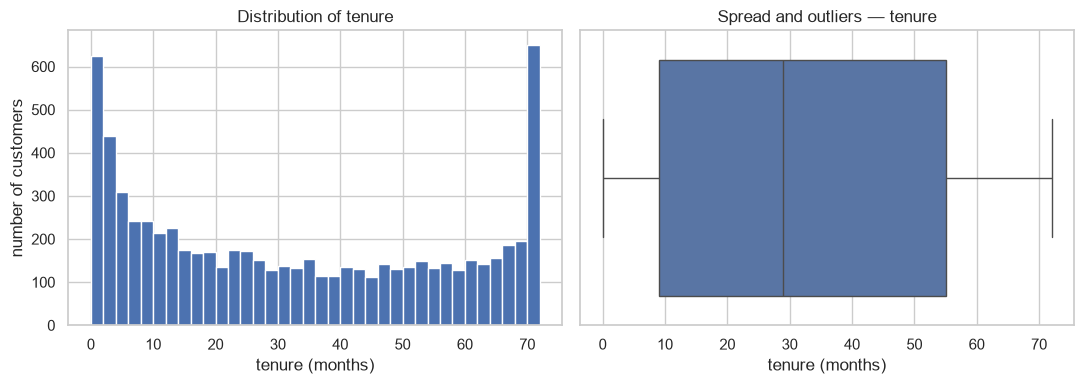

min: 0 | max: 72 | mean: 32.37 | median: 29.0
customers at tenure == 1 : 613
customers at tenure == 72: 362


In [30]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
axes[0].hist(df_clean["tenure"], bins=36, color="#4C72B0", edgecolor="white")
axes[0].set_title("Distribution of tenure")
axes[0].set_xlabel("tenure (months)")
axes[0].set_ylabel("number of customers")

sns.boxplot(x=df_clean["tenure"], ax=axes[1], color="#4C72B0")
axes[1].set_title("Spread and outliers — tenure")
axes[1].set_xlabel("tenure (months)")

plt.tight_layout()
plt.show()

print("min:", df_clean['tenure'].min(), "| max:", df_clean['tenure'].max(),
      "| mean:", round(df_clean['tenure'].mean(), 2), "| median:", df_clean['tenure'].median())
print("customers at tenure == 1 :", (df_clean['tenure'] == 1).sum())
print("customers at tenure == 72:", (df_clean['tenure'] == 72).sum())

> **DRAFT — rewrite in your own words before submitting.**

`tenure` is not a bell curve — it is **U-shaped**, with a tall spike at each end. 613
customers are in their first month and 362 are at the 72-month maximum, and the middle of
the range is comparatively thin. The company therefore has two quite different populations
in one dataset: a large stream of new arrivals and a settled long-term base. The boxplot
shows a wide, symmetric-looking spread (median 29 against a mean of 32.37) and flags no
outliers, which makes sense — 72 months is a ceiling imposed by how long the company has
been collecting data, not an extreme value.

### 5.2 — `MonthlyCharges`

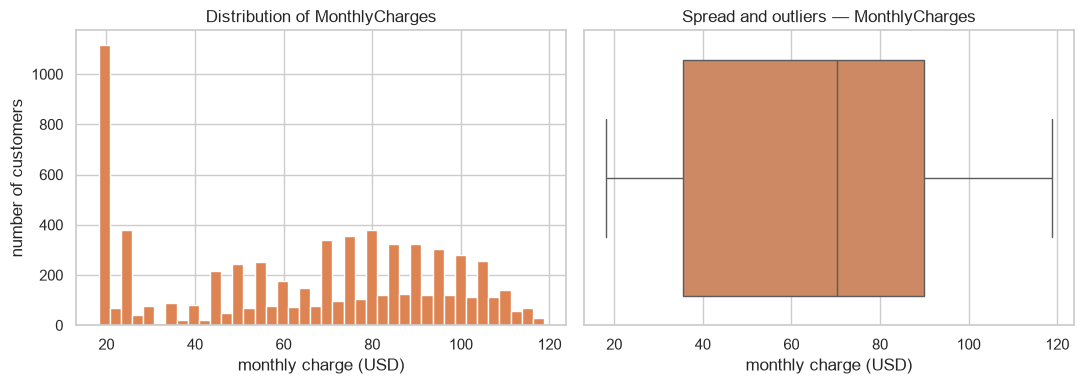

min: 18.25 | max: 118.75 | mean: 64.76 | median: 70.35
customers charged under $30/month: 1653


In [31]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
axes[0].hist(df_clean["MonthlyCharges"], bins=40, color="#DD8452", edgecolor="white")
axes[0].set_title("Distribution of MonthlyCharges")
axes[0].set_xlabel("monthly charge (USD)")
axes[0].set_ylabel("number of customers")

sns.boxplot(x=df_clean["MonthlyCharges"], ax=axes[1], color="#DD8452")
axes[1].set_title("Spread and outliers — MonthlyCharges")
axes[1].set_xlabel("monthly charge (USD)")

plt.tight_layout()
plt.show()

print("min:", df_clean['MonthlyCharges'].min(), "| max:", df_clean['MonthlyCharges'].max(),
      "| mean:", round(df_clean['MonthlyCharges'].mean(), 2),
      "| median:", df_clean['MonthlyCharges'].median())
print("customers charged under $30/month:", (df_clean['MonthlyCharges'] < 30).sum())

> **DRAFT — rewrite in your own words before submitting.**

`MonthlyCharges` is **bimodal**. There is a dense cluster of cheap accounts near the \$18–25
minimum — 1,653 customers pay under \$30 — and then a broad, heavy band from roughly \$70 to
\$110. The gap between them is the product mix rather than a pricing accident: phone-only
customers sit at the bottom and internet (especially fibre) customers sit at the top. This
is why the median (\$70.35) is *above* the mean (\$64.76), and the boxplot correctly reports
no outliers — the full range \$18.25–\$118.75 is simply the company's tariff span.

### 5.3 — `TotalCharges`

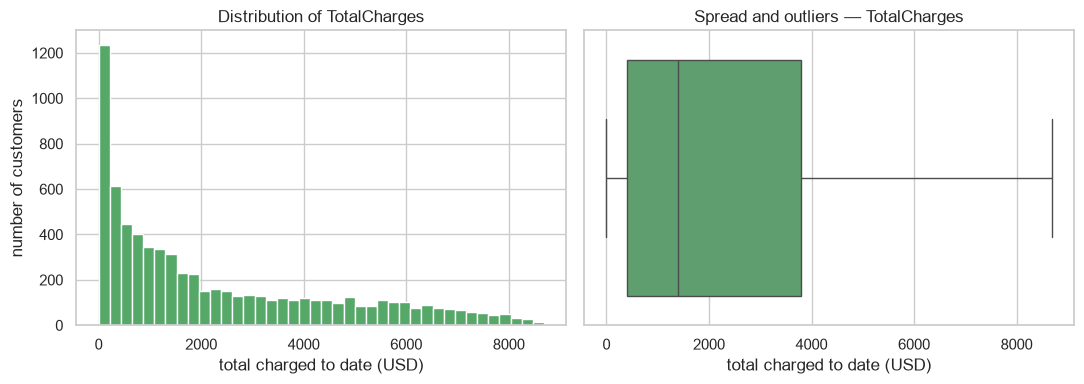

min: 0.0 | max: 8684.8 | mean: 2279.73 | median: 1394.55


In [32]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
axes[0].hist(df_clean["TotalCharges"], bins=40, color="#55A868", edgecolor="white")
axes[0].set_title("Distribution of TotalCharges")
axes[0].set_xlabel("total charged to date (USD)")
axes[0].set_ylabel("number of customers")

sns.boxplot(x=df_clean["TotalCharges"], ax=axes[1], color="#55A868")
axes[1].set_title("Spread and outliers — TotalCharges")
axes[1].set_xlabel("total charged to date (USD)")

plt.tight_layout()
plt.show()

print("min:", df_clean['TotalCharges'].min(), "| max:", df_clean['TotalCharges'].max(),
      "| mean:", round(df_clean['TotalCharges'].mean(), 2),
      "| median:", round(df_clean['TotalCharges'].median(), 2))

> **DRAFT — rewrite in your own words before submitting.**

`TotalCharges` is strongly **right-skewed**: most customers sit near the bottom while a long
tail stretches to \$8,684.80. The mean (\$2,279.73) is well above the median (\$1,394.55),
which is the signature of that tail. This shape is not surprising once you notice what the
column really is — a running total of spending, so it is mostly a restatement of how long
someone has been a customer. The minimum is now \$0.00, which is the 11 tenure-zero customers
filled in Part 4 rather than a data error.

### 5.4 — `Contract`

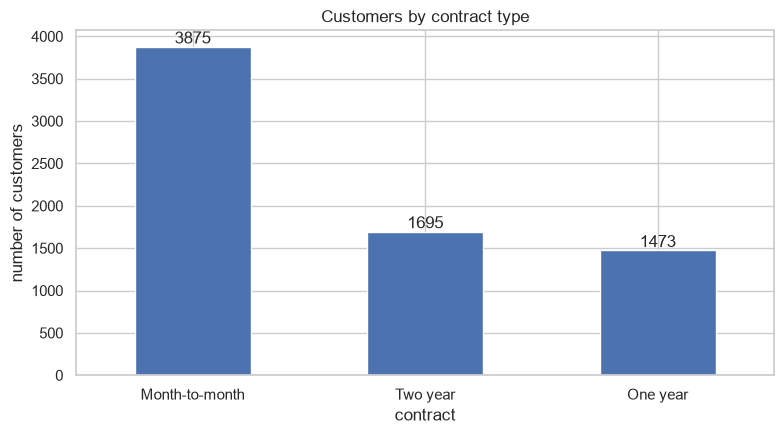

Contract
Month-to-month    3875
Two year          1695
One year          1473
Name: count, dtype: int64

Contract
Month-to-month    55.02
Two year          24.07
One year          20.91
Name: proportion, dtype: float64


In [33]:
counts = df_clean["Contract"].value_counts()
ax = counts.plot(kind="bar", color="#4C72B0", edgecolor="white")
ax.set_title("Customers by contract type")
ax.set_xlabel("contract")
ax.set_ylabel("number of customers")
plt.xticks(rotation=0)
for i, v in enumerate(counts):
    ax.text(i, v + 40, str(v), ha="center")
plt.tight_layout()
plt.show()

print(df_clean["Contract"].value_counts())
print()
print((df_clean["Contract"].value_counts(normalize=True) * 100).round(2))

> **DRAFT — rewrite in your own words before submitting.**

Month-to-month is the single largest group by a wide margin: 3,875 customers, **55.02%** of
the base, against 1,695 on two-year (24.07%) and 1,473 on one-year (20.91%) contracts. More
than half the customer base can therefore leave at any time with no contractual penalty,
which frames the whole churn problem — this is the company's exposure before any behaviour is
even considered.

### 5.5 — `PaymentMethod`

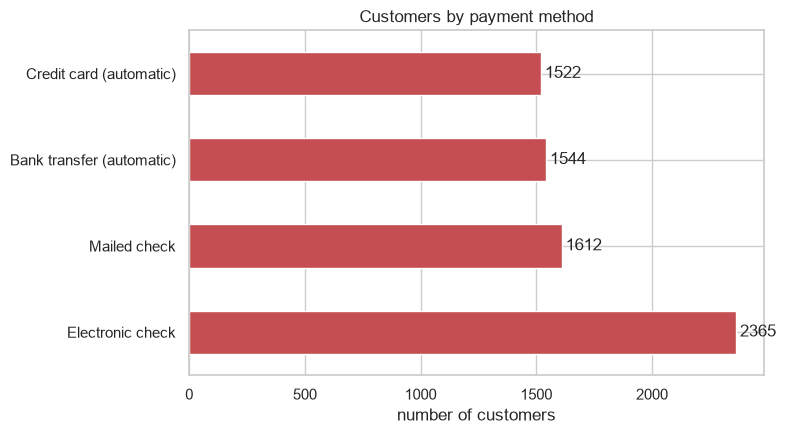

PaymentMethod
Electronic check             2365
Mailed check                 1612
Bank transfer (automatic)    1544
Credit card (automatic)      1522
Name: count, dtype: int64

PaymentMethod
Electronic check             33.58
Mailed check                 22.89
Bank transfer (automatic)    21.92
Credit card (automatic)      21.61
Name: proportion, dtype: float64


In [34]:
counts = df_clean["PaymentMethod"].value_counts()
ax = counts.plot(kind="barh", color="#C44E52", edgecolor="white")
ax.set_title("Customers by payment method")
ax.set_xlabel("number of customers")
ax.set_ylabel("")
for i, v in enumerate(counts):
    ax.text(v + 15, i, str(v), va="center")
plt.tight_layout()
plt.show()

print(df_clean["PaymentMethod"].value_counts())
print()
print((df_clean["PaymentMethod"].value_counts(normalize=True) * 100).round(2))

> **DRAFT — rewrite in your own words before submitting.**

The four payment methods are fairly evenly spread, but Electronic check leads with 2,365
customers (**33.58%**) while the other three sit close together at 21–23%. Grouping them by
how they behave rather than by name is more revealing: the two automatic methods (bank
transfer and credit card) together account for about 43.5% of customers, while the two manual
methods (electronic check and mailed check) account for about 56.5%. Most of the base is
therefore actively confronting a bill each month rather than paying silently.

### 5.6 — Skew and outliers, measured rather than eyeballed

In [35]:
print("=== Skewness ===")
print(df_clean[num_features].skew().round(3))
print()
print("=== Outliers by the 1.5 x IQR rule ===")
for c in num_features:
    q1, q3 = df_clean[c].quantile([0.25, 0.75])
    iqr = q3 - q1
    lo, hi = q1 - 1.5 * iqr, q3 + 1.5 * iqr
    n_out = ((df_clean[c] < lo) | (df_clean[c] > hi)).sum()
    print(f"{c:<16} Q1={q1:>8.2f}  Q3={q3:>8.2f}  IQR={iqr:>8.2f}  "
          f"bounds=[{lo:>9.2f}, {hi:>9.2f}]  outliers={n_out}")

=== Skewness ===
tenure            0.240
MonthlyCharges   -0.221
TotalCharges      0.963
dtype: float64

=== Outliers by the 1.5 x IQR rule ===
tenure           Q1=    9.00  Q3=   55.00  IQR=   46.00  bounds=[   -60.00,    124.00]  outliers=0
MonthlyCharges   Q1=   35.50  Q3=   89.85  IQR=   54.35  bounds=[   -46.02,    171.38]  outliers=0
TotalCharges     Q1=  398.55  Q3= 3786.60  IQR= 3388.05  bounds=[ -4683.52,   8868.67]  outliers=0


> **DRAFT — rewrite in your own words before submitting.**

Measuring instead of eyeballing changes the answer in two places.

**Skew.** `TotalCharges` is clearly right-skewed at **0.963**. `tenure` (**0.240**) and
`MonthlyCharges` (**−0.221**) are both close to symmetric by this measure — but that number
is actively misleading for them. Skewness only measures lopsidedness, and both of those
distributions are *bimodal*: they have two peaks that happen to roughly balance each other
out. A statistic near zero here means "not lopsided", not "normally distributed", and the
histograms above are the reason I can tell the difference.

**Outliers.** The 1.5×IQR rule flags **zero outliers in all three columns**. That is a real
result, not a failed test. Each column is bounded by something concrete — `tenure` by how
long the company has been operating (72 months), `MonthlyCharges` by the published tariff
range, and `TotalCharges` by the product of the two — so no value can run away from the rest.
The visible tail on `TotalCharges` is a genuine long tail of loyal high-spending customers,
not a set of anomalies, and nothing here should be trimmed or capped.

---
# Part 6 — Target Variable Analysis

`Churn` is what Lab 3 will predict. Its distribution has direct consequences for how a
model should later be trained and evaluated.

In [36]:
print("=== Counts ===")
print(df_clean["Churn"].value_counts())
print()
print("=== Proportions (%) ===")
print((df_clean["Churn"].value_counts(normalize=True) * 100).round(2))
print()
n_yes = (df_clean["Churn"] == "Yes").sum()
n_no = (df_clean["Churn"] == "No").sum()
print(f"Imbalance ratio (No : Yes) = {n_no / n_yes:.2f} : 1")

=== Counts ===
Churn
No     5174
Yes    1869
Name: count, dtype: int64

=== Proportions (%) ===
Churn
No     73.46
Yes    26.54
Name: proportion, dtype: float64

Imbalance ratio (No : Yes) = 2.77 : 1


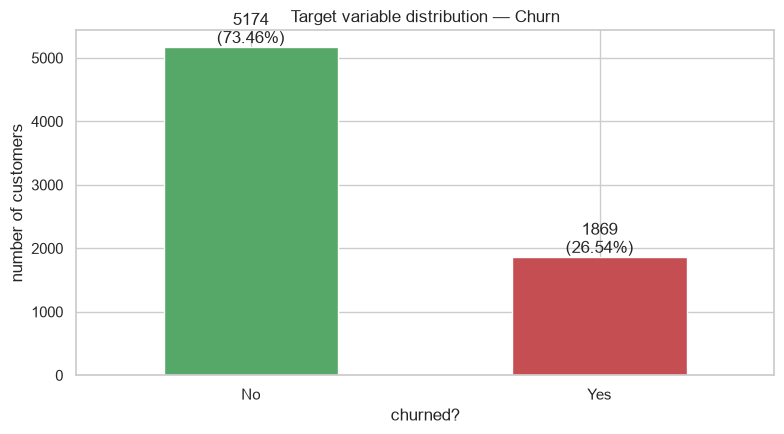

In [37]:
counts = df_clean["Churn"].value_counts()
pct = df_clean["Churn"].value_counts(normalize=True) * 100

ax = counts.plot(kind="bar", color=["#55A868", "#C44E52"], edgecolor="white")
ax.set_title("Target variable distribution — Churn")
ax.set_xlabel("churned?")
ax.set_ylabel("number of customers")
plt.xticks(rotation=0)
for i, (v, p) in enumerate(zip(counts, pct)):
    ax.text(i, v + 60, f"{v}\n({p:.2f}%)", ha="center")
plt.tight_layout()
plt.show()

> **DRAFT — rewrite in your own words before submitting.**

The target is **imbalanced, though not severely**: 5,174 customers stayed (**73.46%**) and
1,869 left (**26.54%**), a ratio of **2.77 : 1**. Roughly one customer in four churned.

**Why this matters when a model is trained in Lab 3** (not how to fix it):

Accuracy stops being a meaningful score. A model that ignores every feature and predicts
"No" for all 7,043 customers is **73.46% accurate** while identifying not one of the 1,869
customers the company actually cares about. Any reported accuracy therefore has to be
compared against that 73.46% floor before it means anything.

The imbalance also biases what the model learns. Most classifiers minimise total error, and
with 2.77 non-churners for every churner the cheapest way to reduce error is to lean towards
"No" — so the minority class tends to be under-predicted precisely because it is the minority.

Finally, the business cost of the two mistakes is not symmetric. Missing a real churner loses
a customer; wrongly flagging a loyal one costs a retention offer. Since these are not equally
expensive, the evaluation in Lab 3 will need metrics that look at the churn class
specifically — precision, recall, F1 — rather than one overall accuracy figure.

---
# Part 7 — Bivariate Analysis: Features vs. Churn

Categorical features are compared using churn *rate* per category (a raw count would just
re-show which category is largest); numerical features are compared with boxplots across
the two churn classes.

In [38]:
overall_rate = (df_clean["Churn"] == "Yes").mean() * 100
print(f"Overall churn rate (baseline for every comparison below): {overall_rate:.2f}%")

Overall churn rate (baseline for every comparison below): 26.54%


### 7.1 — `Contract` vs. Churn

Churn rate (%) by Contract:
Churn              No    Yes
Contract                    
Month-to-month  57.29  42.71
One year        88.73  11.27
Two year        97.17   2.83

Group sizes:
Contract
Month-to-month    3875
Two year          1695
One year          1473
Name: count, dtype: int64


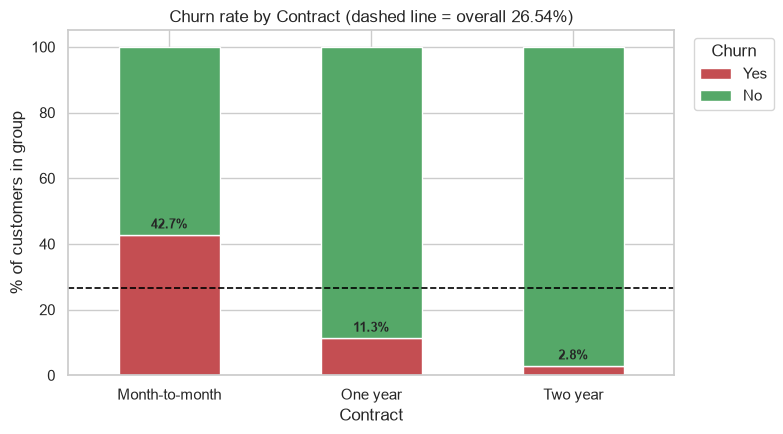

In [39]:
ct = pd.crosstab(df_clean["Contract"], df_clean["Churn"], normalize="index") * 100
print("Churn rate (%) by Contract:")
print(ct.round(2))
print()
print("Group sizes:")
print(df_clean["Contract"].value_counts())

# 'Yes' is stacked first so the churned share rises from zero and can be read directly
# against the dashed baseline; with 'No' at the bottom the reference line would sit under
# an unrelated segment and mean nothing.
ax = ct[["Yes", "No"]].plot(kind="bar", stacked=True, color=["#C44E52", "#55A868"],
                            edgecolor="white")
ax.axhline(overall_rate, color="black", linestyle="--", linewidth=1.2)
ax.set_title("Churn rate by Contract (dashed line = overall {:.2f}%)".format(overall_rate))
ax.set_ylabel("% of customers in group")
for i, v in enumerate(ct["Yes"]):
    ax.text(i, v + 2, f"{v:.1f}%", ha="center", fontsize=9, fontweight="bold")
ax.set_xlabel("Contract")
ax.legend(title="Churn", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

> **DRAFT — rewrite in your own words before submitting.**

**Observation.** Contract length is the strongest single predictor of churn found anywhere in
this notebook, and the relationship is monotonic — the longer the commitment, the lower the
churn.

**Evidence.** Churn rate runs **42.71%** on month-to-month, **11.27%** on one-year and
**2.83%** on two-year contracts. Against the 26.54% baseline, a month-to-month customer is
about 1.6× the average risk and a two-year customer roughly one tenth of it — a **15-fold
spread** between the extremes. The effect is not a small-sample artefact: the groups hold
3,875, 1,473 and 1,695 customers respectively.

**Possible explanation.** Two mechanisms are tangled here and this chart cannot separate
them. The obvious one is friction: a month-to-month customer can leave whenever they like,
while a two-year customer would have to break a contract to do so. The subtler one is
self-selection — customers who already intend to stay are the ones willing to sign a long
contract, so the contract may be *marking* loyal customers as much as *causing* loyalty.
That distinction matters commercially: if it is friction, pushing customers onto long
contracts will reduce churn; if it is self-selection, it will mostly change who signs up.

### 7.2 — `PaymentMethod` vs. Churn

Churn rate (%) by PaymentMethod:
Churn                         No    Yes
PaymentMethod                          
Bank transfer (automatic)  83.29  16.71
Credit card (automatic)    84.76  15.24
Electronic check           54.71  45.29
Mailed check               80.89  19.11

Group sizes:
PaymentMethod
Electronic check             2365
Mailed check                 1612
Bank transfer (automatic)    1544
Credit card (automatic)      1522
Name: count, dtype: int64


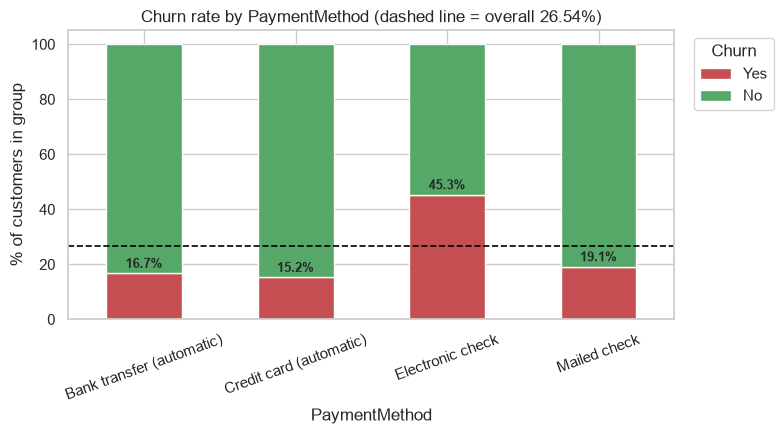

In [40]:
ct = pd.crosstab(df_clean["PaymentMethod"], df_clean["Churn"], normalize="index") * 100
print("Churn rate (%) by PaymentMethod:")
print(ct.round(2))
print()
print("Group sizes:")
print(df_clean["PaymentMethod"].value_counts())

# 'Yes' is stacked first so the churned share rises from zero and can be read directly
# against the dashed baseline; with 'No' at the bottom the reference line would sit under
# an unrelated segment and mean nothing.
ax = ct[["Yes", "No"]].plot(kind="bar", stacked=True, color=["#C44E52", "#55A868"],
                            edgecolor="white")
ax.axhline(overall_rate, color="black", linestyle="--", linewidth=1.2)
ax.set_title("Churn rate by PaymentMethod (dashed line = overall {:.2f}%)".format(overall_rate))
ax.set_ylabel("% of customers in group")
for i, v in enumerate(ct["Yes"]):
    ax.text(i, v + 2, f"{v:.1f}%", ha="center", fontsize=9, fontweight="bold")
ax.set_xlabel("PaymentMethod")
ax.legend(title="Churn", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.xticks(rotation=20)
plt.tight_layout()
plt.show()

> **DRAFT — rewrite in your own words before submitting.**

**Observation.** Payment method splits cleanly into one high-risk group and three low-risk
ones, and the split is not really about the method itself.

**Evidence.** Electronic check churns at **45.29%** — well above the 26.54% baseline — while
mailed check (**19.11%**), bank transfer (**16.71%**) and credit card (**15.24%**) all sit
below it. Electronic check is also the largest group at 2,365 customers, so this is a
substantial slice of the base, not a fringe segment.

**Possible explanation.** The two *automatic* methods sit lowest, which fits a friction
story: automatic payment renews silently, so leaving requires a deliberate act of cancelling.
But mailed check is manual too and still churns at only 19.11%, so friction alone does not
explain it. The more likely reading is that electronic check is acting as a proxy for
something else — Part 7.3 shows fibre customers churn heavily, and electronic check is
plausibly the method that segment tends to use. This is a correlation whose cause probably
lies in another column, and I would not treat it as a lever on its own.

### 7.3 — `InternetService` vs. Churn

Churn rate (%) by InternetService:
Churn               No    Yes
InternetService              
DSL              81.04  18.96
Fiber optic      58.11  41.89
No               92.60   7.40

Group sizes:
InternetService
Fiber optic    3096
DSL            2421
No             1526
Name: count, dtype: int64


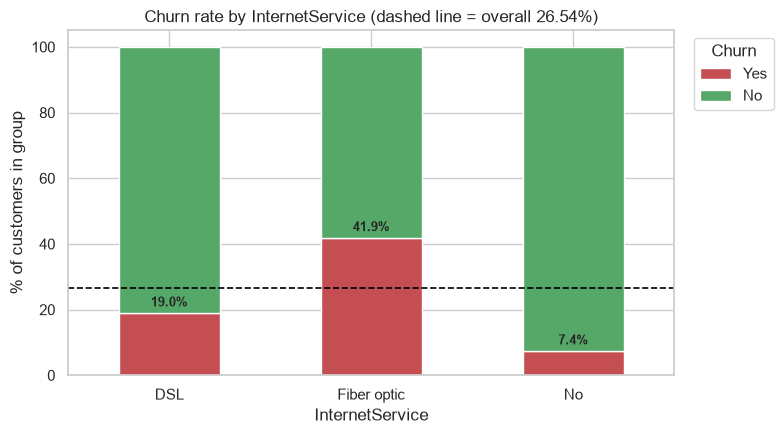

In [41]:
ct = pd.crosstab(df_clean["InternetService"], df_clean["Churn"], normalize="index") * 100
print("Churn rate (%) by InternetService:")
print(ct.round(2))
print()
print("Group sizes:")
print(df_clean["InternetService"].value_counts())

# 'Yes' is stacked first so the churned share rises from zero and can be read directly
# against the dashed baseline; with 'No' at the bottom the reference line would sit under
# an unrelated segment and mean nothing.
ax = ct[["Yes", "No"]].plot(kind="bar", stacked=True, color=["#C44E52", "#55A868"],
                            edgecolor="white")
ax.axhline(overall_rate, color="black", linestyle="--", linewidth=1.2)
ax.set_title("Churn rate by InternetService (dashed line = overall {:.2f}%)".format(overall_rate))
ax.set_ylabel("% of customers in group")
for i, v in enumerate(ct["Yes"]):
    ax.text(i, v + 2, f"{v:.1f}%", ha="center", fontsize=9, fontweight="bold")
ax.set_xlabel("InternetService")
ax.legend(title="Churn", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

> **DRAFT — rewrite in your own words before submitting.**

**Observation.** Fibre optic customers churn at more than five times the rate of customers
with no internet service at all.

**Evidence.** **41.89%** of fibre customers churned, against **18.96%** on DSL and **7.40%**
for customers with no internet service. Fibre is also the largest group (3,096 customers), so
the company's most-subscribed internet product is also its least sticky.

**Possible explanation.** This is the most commercially interesting result in the notebook,
because fibre is the premium product and would normally be expected to retain best. Two
readings fit. Fibre is the most competitive part of the market, so those customers are the
most actively courted by rivals and the most able to switch. Alternatively — and more
worryingly for the company — it may signal a service or value problem: fibre customers pay
the most (mean \$91.50/month against \$21.08 for phone-only, from Part 12) and may not feel
they are getting proportionate value. The data here cannot distinguish a competitive-market
effect from a dissatisfaction effect, and separating them would need service-quality or
complaints data that this dataset does not contain.

### 7.4 — `gender` vs. Churn — testing the Part 1 prediction

Churn rate (%) by gender:
Churn      No    Yes
gender              
Female  73.08  26.92
Male    73.84  26.16

Group sizes:
gender
Male      3555
Female    3488
Name: count, dtype: int64


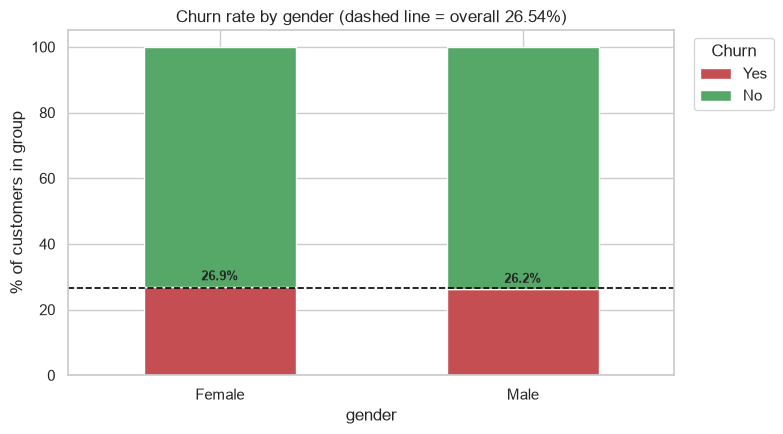

In [42]:
ct = pd.crosstab(df_clean["gender"], df_clean["Churn"], normalize="index") * 100
print("Churn rate (%) by gender:")
print(ct.round(2))
print()
print("Group sizes:")
print(df_clean["gender"].value_counts())

# 'Yes' is stacked first so the churned share rises from zero and can be read directly
# against the dashed baseline; with 'No' at the bottom the reference line would sit under
# an unrelated segment and mean nothing.
ax = ct[["Yes", "No"]].plot(kind="bar", stacked=True, color=["#C44E52", "#55A868"],
                            edgecolor="white")
ax.axhline(overall_rate, color="black", linestyle="--", linewidth=1.2)
ax.set_title("Churn rate by gender (dashed line = overall {:.2f}%)".format(overall_rate))
ax.set_ylabel("% of customers in group")
for i, v in enumerate(ct["Yes"]):
    ax.text(i, v + 2, f"{v:.1f}%", ha="center", fontsize=9, fontweight="bold")
ax.set_xlabel("gender")
ax.legend(title="Churn", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

> **DRAFT — rewrite in your own words before submitting.**

**Observation.** `gender` has essentially no relationship with churn — the Part 1 prediction
that it would be useless is confirmed.

**Evidence.** Female customers churn at **26.92%** and male customers at **26.16%**, a
difference of **0.76 percentage points** against a 26.54% baseline. Both groups are large
(3,488 and 3,555), so this is not an under-powered comparison — the gap is genuinely tiny,
and both bars sit visually on the overall-rate line.

**Possible explanation.** There is no plausible mechanism connecting gender to a decision to
switch telecoms provider, and the data agrees. This is worth stating explicitly rather than
quietly dropping the column: a feature that carries no signal adds dimensionality and noise
to a model without adding predictive power, and gender in particular raises fairness concerns
if a retention model were ever to act on it. I have kept it in `clean_churn.csv` so the
finding stays reproducible, but flagged it in Part 10 as a candidate for removal.

### 7.5 — `tenure` vs. Churn

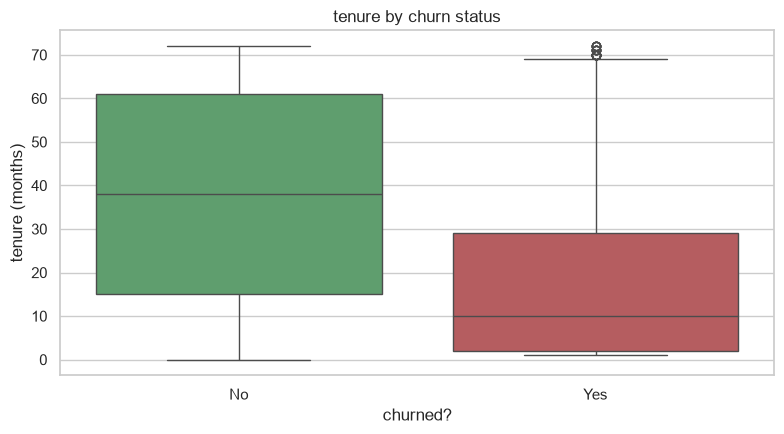

        count   mean    std  min   25%   50%   75%   max
Churn                                                   
No     5174.0  37.57  24.11  0.0  15.0  38.0  61.0  72.0
Yes    1869.0  17.98  19.53  1.0   2.0  10.0  29.0  72.0


In [43]:
ax = sns.boxplot(x="Churn", y="tenure", data=df_clean, hue="Churn",
                 palette=["#55A868", "#C44E52"], legend=False)
ax.set_title("tenure by churn status")
ax.set_xlabel("churned?")
ax.set_ylabel("tenure (months)")
plt.tight_layout()
plt.show()

print(df_clean.groupby("Churn")["tenure"].describe().round(2))

In [44]:
# The boxplot shows the two groups differ, but not how the risk decays. Bucket tenure to
# see the shape of that decay.
buckets = pd.cut(df_clean["tenure"], [-0.1, 1, 6, 12, 24, 48, 72],
                 labels=["0-1", "2-6", "7-12", "13-24", "25-48", "49-72"])
by_bucket = pd.DataFrame({
    "customers": df_clean.groupby(buckets, observed=True).size(),
    "churn_rate_%": (df_clean.assign(_y=df_clean["Churn"].eq("Yes"))
                     .groupby(buckets, observed=True)["_y"].mean() * 100).round(2),
})
print(by_bucket)
print()
print("Churn rate among tenure == 1 customers:",
      round(df_clean.loc[df_clean["tenure"] == 1, "Churn"].eq("Yes").mean() * 100, 2), "%")

        customers  churn_rate_%
tenure                         
0-1           624         60.90
2-6           857         47.14
7-12          705         35.89
13-24        1024         28.71
25-48        1594         20.39
49-72        2239          9.51

Churn rate among tenure == 1 customers: 61.99 %


> **DRAFT — rewrite in your own words before submitting.**

**Observation.** Churn is heavily concentrated in a customer's first months, and the risk
decays steadily with every month survived. This directly answers the first question posed in
Part 1.

**Evidence.** Churned customers have a mean tenure of **17.98 months** against **37.57** for
those who stayed, and the medians are further apart still (**10** vs **38**). The quartiles
are the sharpest evidence: 25% of churners left within **2 months**, and 75% left within
**29**. The bucketed rates show the decay cleanly — **60.90%** at 0–1 months, 47.14% at 2–6,
35.89% at 7–12, 28.71% at 13–24, 20.39% at 25–48 and just **9.51%** at 49–72 months.
Customers in month 1 alone churn at **61.99%**.

**Possible explanation.** This looks like an onboarding problem rather than a loyalty
problem. New customers have no habit, no sunk cost and no accumulated switching friction, and
are also the most likely to have just discovered that the service does not match what they
expected when they signed up. Every month survived both selects for customers who were a good
fit and adds a little more inertia. Commercially the implication is concrete: retention
effort aimed at the first six months addresses far more churn than effort spread evenly
across the base — but note the causal direction is ambiguous, since short tenure is partly a
*consequence* of leaving early, not only a cause of it.

### 7.6 — `MonthlyCharges` vs. Churn

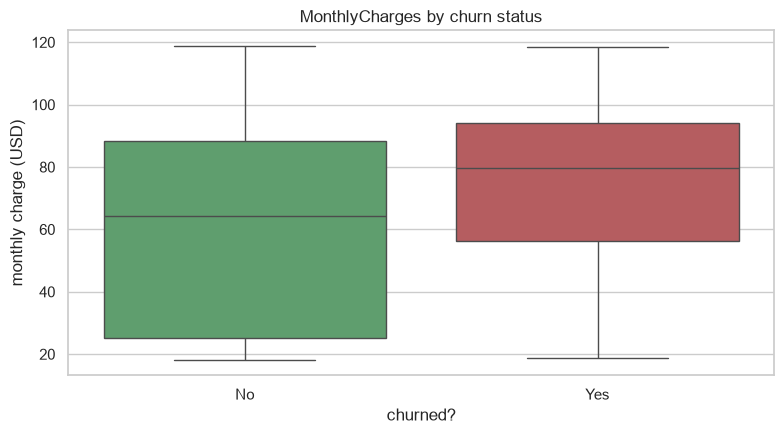

        count   mean    std    min    25%    50%   75%     max
Churn                                                         
No     5174.0  61.27  31.09  18.25  25.10  64.43  88.4  118.75
Yes    1869.0  74.44  24.67  18.85  56.15  79.65  94.2  118.35


In [45]:
ax = sns.boxplot(x="Churn", y="MonthlyCharges", data=df_clean, hue="Churn",
                 palette=["#55A868", "#C44E52"], legend=False)
ax.set_title("MonthlyCharges by churn status")
ax.set_xlabel("churned?")
ax.set_ylabel("monthly charge (USD)")
plt.tight_layout()
plt.show()

print(df_clean.groupby("Churn")["MonthlyCharges"].describe().round(2))

> **DRAFT — rewrite in your own words before submitting.**

**Observation.** Churners pay noticeably more per month than customers who stay, and the
difference is concentrated at the bottom of the distribution rather than the top.

**Evidence.** Mean monthly charge is **\$74.44** for churners against **\$61.27** for
non-churners, and the medians are **\$79.65** vs **\$64.43**. The revealing figure is the
lower quartile: **\$56.15** for churners against **\$25.10** for non-churners. The maxima are
almost identical (\$118.35 vs \$118.75), so this is not about the most expensive customers
leaving — it is that **cheap customers almost never leave**, which pulls the retained group's
distribution down.

**Possible explanation.** Read together with Part 5.2, the low-charge cluster is largely
phone-only customers on minimal tariffs, who have little to save by switching and little to
be dissatisfied with. Higher bills give a competitor more room to undercut and make the
customer scrutinise the service more closely. Much of this is likely the same effect seen in
Part 7.3 rather than an independent one, since fibre customers are both the most expensive
and the most likely to leave.

### 7.7 — `TotalCharges` vs. Churn

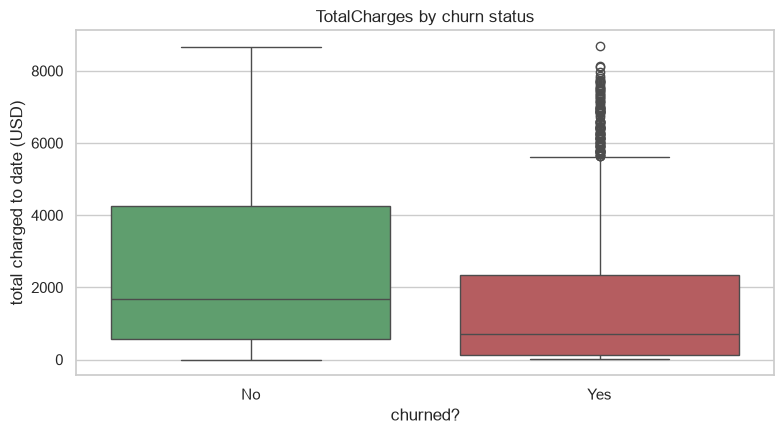

        count     mean      std    min    25%      50%      75%      max
Churn                                                                   
No     5174.0  2549.91  2329.95   0.00  572.9  1679.52  4262.85  8672.45
Yes    1869.0  1531.80  1890.82  18.85  134.5   703.55  2331.30  8684.80


In [46]:
ax = sns.boxplot(x="Churn", y="TotalCharges", data=df_clean, hue="Churn",
                 palette=["#55A868", "#C44E52"], legend=False)
ax.set_title("TotalCharges by churn status")
ax.set_xlabel("churned?")
ax.set_ylabel("total charged to date (USD)")
plt.tight_layout()
plt.show()

print(df_clean.groupby("Churn")["TotalCharges"].describe().round(2))

> **DRAFT — rewrite in your own words before submitting.**

**Observation.** Churners have accumulated far less total spending — but this chart is much
less informative than it first appears.

**Evidence.** Mean `TotalCharges` is **\$1,531.80** for churners against **\$2,549.91** for
non-churners, with medians of **\$703.55** and **\$1,679.52**.

**Possible explanation.** This is very largely the tenure effect in disguise, not a separate
finding. Part 8 shows `TotalCharges` correlates with `tenure` at **r = 0.83**, so a group
that left early has necessarily had fewer months in which to accumulate charges. The
difference is close to arithmetic rather than behavioural: it says churners were customers
for less time, which Part 7.5 already established directly and more clearly. I would treat
this as a weaker restatement of the tenure result rather than independent evidence — and it is
the reason `TotalCharges` is singled out for caution in Part 9.

---
# Part 8 — Correlation & Feature Relationships

Numerical features can be related to each other, not just to the target. Note that
`SeniorCitizen` is deliberately absent: Part 4 converted it to Yes/No, so the only genuine
numerical features left are the three below.

In [47]:
corr_matrix = df_clean.corr(numeric_only=True)
corr_matrix.round(4)

,tenure,MonthlyCharges,TotalCharges
tenure,1.0000,0.2479,0.8262
MonthlyCharges,0.2479,1.0000,0.6512
TotalCharges,0.8262,0.6512,1.0000


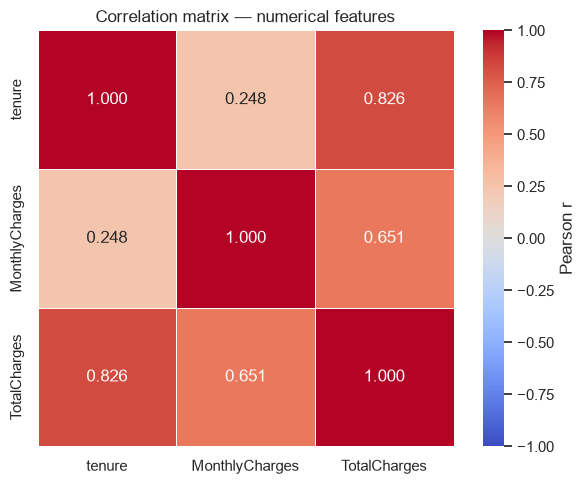

In [48]:
fig, ax = plt.subplots(figsize=(6.5, 5))
sns.heatmap(corr_matrix, annot=True, fmt=".3f", cmap="coolwarm", vmin=-1, vmax=1,
            square=True, linewidths=0.5, cbar_kws={"label": "Pearson r"}, ax=ax)
ax.set_title("Correlation matrix — numerical features")
plt.tight_layout()
plt.show()

In [49]:
# Rank the pairs so "most correlated" is a measured claim rather than an impression.
pairs = (corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))
         .stack()
         .dropna()
         .sort_values(key=abs, ascending=False))
print("Feature pairs ranked by |correlation|:")
print(pairs.round(4))
print()
# TotalCharges should be close to tenure * MonthlyCharges if it is a running total.
approx = df_clean["tenure"] * df_clean["MonthlyCharges"]
print("Correlation between TotalCharges and (tenure x MonthlyCharges):",
      round(df_clean["TotalCharges"].corr(approx), 4))

Feature pairs ranked by |correlation|:
tenure          TotalCharges      0.8262
MonthlyCharges  TotalCharges      0.6512
tenure          MonthlyCharges    0.2479
dtype: float64

Correlation between TotalCharges and (tenure x MonthlyCharges): 0.9996


> **DRAFT — rewrite in your own words before submitting.**

**Most correlated pairs**, ranked by absolute correlation:

| Pair | r |
|---|---|
| `tenure` ↔ `TotalCharges` | **0.826** |
| `MonthlyCharges` ↔ `TotalCharges` | **0.651** |
| `tenure` ↔ `MonthlyCharges` | 0.248 |

The two strong pairs both involve `TotalCharges`, and the reason is mechanical rather than
behavioural: `TotalCharges` is roughly `tenure × MonthlyCharges`. The check at the bottom of
the section confirms this almost exactly — the correlation between `TotalCharges` and
`tenure × MonthlyCharges` is **0.9996**. `TotalCharges` is therefore very nearly a derived
column, carrying little information the other two do not already hold.

*(`SeniorCitizen` is absent from this matrix by design: Part 4 converted it to `Yes`/`No`,
so it is no longer numeric. Its 0/1 encoding would have produced a correlation coefficient
that was arithmetically valid and completely meaningless.)*

**Correlation vs. causation, and the redundancy risk.** None of these correlations describe
one variable causing another. `tenure` and `TotalCharges` move together because of how
`TotalCharges` is *defined* — staying longer does not "cause" higher lifetime spend so much
as arithmetically produce it. Reading a causal story into this would be a mistake in an even
more basic way than usual, because there is no behaviour involved at all.

The practical risk for Lab 3 is redundancy. Feeding all three into a linear or
logistic model means supplying a feature that is nearly a deterministic function of the other
two. This inflates and destabilises coefficient estimates (multicollinearity): the model can
trade weight between `tenure` and `TotalCharges` almost freely, so the individual
coefficients become unreliable as statements about which factor matters, even though overall
predictive accuracy may barely change. Tree-based models are largely untroubled by this, but
would still gain nothing from the third column. Note the correlation matrix covers only the
three numerical features — it says nothing about the categorical columns, and Part 7 shows
`Contract` is a far stronger churn signal than any of these.

---
# Part 9 — Data Leakage Awareness

Before training anything in Lab 3, check whether any column carries information that would
not realistically be available at the moment of prediction.

In [50]:
# Evidence for the discussion below: how distinctive is customerID, and how tightly is
# TotalCharges tied to how long a customer has already stayed?
print("customerID -- distinct values:", df["customerID"].nunique(), "of", len(df), "rows")
print("            unique per row  :", df["customerID"].is_unique)
print()
print("corr(TotalCharges, tenure) :", round(df_clean["TotalCharges"].corr(df_clean["tenure"]), 4))
print()
print("Mean tenure by churn status:")
print(df_clean.groupby("Churn")["tenure"].mean().round(2))

customerID -- distinct values: 7043 of 7043 rows
            unique per row  : True

corr(TotalCharges, tenure) : 0.8262

Mean tenure by churn status:
Churn
No     37.57
Yes    17.98
Name: tenure, dtype: float64


> **DRAFT — rewrite in your own words before submitting.**

**Suspect 1 — `customerID` (certain; remove).** It holds 7,043 distinct values across 7,043
rows, one per customer. It is not leakage in the strict "known only after the outcome" sense,
but it is useless and actively harmful: a model given a column that uniquely identifies every
row can memorise individual customers rather than learn any pattern, and whatever it learns
cannot transfer to a new customer whose ID it has never seen. It is dropped in Part 11.

**Suspect 2 — `TotalCharges` (genuine concern; kept, but flagged).** This is the interesting
case, and the argument needs to be made carefully rather than asserted.

`TotalCharges` is a *running* total: it keeps growing for as long as a customer stays. Its
value at extraction time therefore partly encodes how long the customer's relationship lasted
— which, for a customer who has already left, is a fact about the outcome. Part 7.7 shows
churners average \$1,531.80 against \$2,549.91 for non-churners, and Part 8 shows it
correlates with `tenure` at r = 0.83, so it is not carrying much independent information to
justify the risk.

I want to be precise about how serious this is, because it is easy to overstate. This is
**not** clean leakage in the way that, say, a `cancellation_date` column would be — nothing
here is recorded only at the moment of churn, and `TotalCharges` is genuinely observable for
an active customer today. The problem is subtler: the dataset is a single snapshot, so for
churned customers the column was frozen when they left, while for active customers it is
still accruing. The two groups' values were measured at different points in their lifecycles,
and that difference is correlated with the label.

**The same caution applies to `tenure`**, for the same reason and to a lesser degree, which
is why I have not dropped either. Removing both would gut the dataset.

**Not suspects.** `Contract`, `InternetService`, `PaymentMethod`, `MonthlyCharges` and the
demographic and service columns all describe a customer's current standing arrangements, are
knowable at any moment for an active customer, and do not depend on the outcome.

> **DRAFT — rewrite in your own words before submitting.**

**What goes wrong if such a column is left in.** The model looks excellent in testing and
fails in production. A leaked column lets the model shortcut the actual problem: it scores
highly on held-out data because that data carries the same after-the-fact information, so
validation confirms a skill the model does not have. The failure only surfaces at deployment,
where the company needs a prediction for a customer who has *not* yet churned — and the
leaked column simply does not hold the outcome-revealing value it held during training.

The damage is worse than a merely inaccurate model, in two ways. First, a leaked feature
dominates training, so genuinely useful signals like `Contract` get crowded out and their
learned importance is suppressed — the model is not just wrong, it has learned the wrong
thing. Second, the false confidence is expensive: retention budget gets aimed at whoever the
broken model flags, and the customers who were actually about to leave are missed. For
`customerID` the practical consequence is different but also bad — it invites memorisation
and guarantees the model cannot generalise to any customer it has not already seen.

---
# Part 10 — ML-Readiness Checklist

Every column's fate in one table. Lab 3 will use this directly.

In [51]:
# Generated so that no column can be silently skipped from the table below.
readiness = pd.DataFrame({
    "Column": df_clean.columns,
    "dtype_after_cleaning": [str(df_clean[c].dtype) for c in df_clean.columns],
    "n_unique": [df_clean[c].nunique() for c in df_clean.columns],
})
print("Columns that must appear in the readiness table:", len(readiness))
readiness

Columns that must appear in the readiness table: 21


,Column,dtype_after_cleaning,n_unique
0,customerID,str,7043
1,gender,str,2
2,SeniorCitizen,str,2
3,Partner,str,2
4,Dependents,str,2
5,tenure,int64,73
6,PhoneService,str,2
7,MultipleLines,str,3
8,InternetService,str,3
9,OnlineSecurity,str,3


> **DRAFT — rewrite in your own words before submitting.**

All 21 columns of `df_clean` are listed — the row count is asserted by the cell above. Type
and Action reflect the technical work already done in Parts 3, 4 and 8; the **Reason** column
is the part to rewrite in your own words.

*"Encode in Lab 3" is a note about what Lab 3 must do, not something performed here — no
encoding takes place in this notebook.*

| Column | Type | Role | Action | Reason |
|---|---|---|---|---|
| `customerID` | Identifier | — | **Remove** | _(draft)_ Unique across all 7,043 rows; labels a customer without describing one. Invites memorisation and cannot generalise (Part 9). |
| `gender` | Categorical (binary) | Feature | Keep, but flagged | _(draft)_ Part 7.4 measured 26.92% vs 26.16% churn — a 0.76pp gap, effectively no signal. Retained for reproducibility; the first candidate to drop, and a fairness risk if ever acted on. |
| `SeniorCitizen` | Categorical (binary) | Feature | Keep — dtype fixed | _(draft)_ Was `int64` 0/1, which invited meaningless arithmetic; remapped to `No`/`Yes` in Part 4 to match the other yes/no columns. Encode in Lab 3. |
| `Partner` | Categorical (binary) | Feature | Keep | _(draft)_ Household context, plausibly linked to stability. Clean, 2 values, no action needed beyond encoding. |
| `Dependents` | Categorical (binary) | Feature | Keep | _(draft)_ Same reasoning as `Partner`; clean and complete. |
| `tenure` | Numerical | Feature | Keep — consider scaling | _(draft)_ The second-strongest signal found (Part 7.5: 60.90% churn at 0–1 months falling to 9.51% at 49–72). Range 0–72 vs `TotalCharges`' 0–8,684, so scaling matters for distance- and gradient-based models. Carries the mild snapshot caveat from Part 9. |
| `PhoneService` | Categorical (binary) | Feature | Keep | _(draft)_ Clean. Note it fully determines the `'No phone service'` level of `MultipleLines`. |
| `MultipleLines` | Categorical (3-level) | Feature | Keep — collapse in Lab 3 | _(draft)_ Its third level `'No phone service'` (682 rows) exactly restates `PhoneService == 'No'` (Part 2.3). Collapsing to Yes/No removes a redundant dummy column. |
| `InternetService` | Categorical (3-level) | Feature | Keep | _(draft)_ Strong signal — 41.89% churn on fibre vs 7.40% on none (Part 7.3). Also the parent of the six sentinel columns below. |
| `OnlineSecurity` | Categorical (3-level) | Feature | Keep — collapse in Lab 3 | _(draft)_ `'No internet service'` (1,526 rows) is exactly `InternetService == 'No'`; redundant as a third level. |
| `OnlineBackup` | Categorical (3-level) | Feature | Keep — collapse in Lab 3 | _(draft)_ Same sentinel redundancy as `OnlineSecurity`, same 1,526 rows. |
| `DeviceProtection` | Categorical (3-level) | Feature | Keep — collapse in Lab 3 | _(draft)_ Same sentinel redundancy, same 1,526 rows. |
| `TechSupport` | Categorical (3-level) | Feature | Keep — collapse in Lab 3 | _(draft)_ Same sentinel redundancy, same 1,526 rows. |
| `StreamingTV` | Categorical (3-level) | Feature | Keep — collapse in Lab 3 | _(draft)_ Same sentinel redundancy, same 1,526 rows. |
| `StreamingMovies` | Categorical (3-level) | Feature | Keep — collapse in Lab 3 | _(draft)_ Same sentinel redundancy, same 1,526 rows. |
| `Contract` | Categorical (3-level, ordinal) | Feature | Keep | _(draft)_ The strongest predictor found (Part 7.1: 42.71% → 11.27% → 2.83%). Its levels have a natural order, so ordinal encoding is worth comparing against one-hot in Lab 3. |
| `PaperlessBilling` | Categorical (binary) | Feature | Keep | _(draft)_ Clean, complete, plausibly a proxy for billing engagement. |
| `PaymentMethod` | Categorical (4-level) | Feature | Keep | _(draft)_ Electronic check churns at 45.29% vs ~15–19% elsewhere (Part 7.2). No natural order, so one-hot rather than ordinal. |
| `MonthlyCharges` | Numerical | Feature | Keep — consider scaling | _(draft)_ Real signal (Part 7.6: \$74.44 vs \$61.27 mean) and, unlike `TotalCharges`, a current-state fact carrying no snapshot caveat. |
| `TotalCharges` | Numerical | Feature | **Keep with caution** | _(draft)_ Repaired in Part 4, but r = 0.83 with `tenure` and ≈ `tenure × MonthlyCharges` at r = 0.9996 (Part 8), so it is nearly derived. Also the main snapshot-leakage concern of Part 9. Test explicitly in Lab 3 whether dropping it changes anything. |
| `Churn` | Categorical (binary) | **Target** | Keep as target | _(draft)_ The variable to predict. Imbalanced at 73.46% / 26.54% (Part 6), so Lab 3 must report precision/recall/F1 rather than accuracy alone. Never to be used as an input feature. |

---
# Part 11 — Building the Clean Dataset

Every cleaning decision brought together into one final dataframe that Lab 3 can load
directly. No train/test split, no encoding, no model — those are Lab 3's job.

In [52]:
clean_df = df_clean.copy()

# Drop the identifier: it is unique per row, carries no information about behaviour, and
# a model given it could only memorise individual customers.
clean_df = clean_df.drop(columns=["customerID"])

print("df_clean :", df_clean.shape, "(includes customerID)")
print("clean_df :", clean_df.shape, "(identifier removed)")
print()
print("Columns retained:")
for i, c in enumerate(clean_df.columns, 1):
    print(f"  {i:2d}. {c}")

df_clean : (7043, 21) (includes customerID)
clean_df : (7043, 20) (identifier removed)

Columns retained:
   1. gender
   2. SeniorCitizen
   3. Partner
   4. Dependents
   5. tenure
   6. PhoneService
   7. MultipleLines
   8. InternetService
   9. OnlineSecurity
  10. OnlineBackup
  11. DeviceProtection
  12. TechSupport
  13. StreamingTV
  14. StreamingMovies
  15. Contract
  16. PaperlessBilling
  17. PaymentMethod
  18. MonthlyCharges
  19. TotalCharges
  20. Churn


#### A consequence of dropping the identifier, and the decision taken

Dropping `customerID` re-opens the duplicate question from Part 3. The check below is run
*after* the drop, because that is the only point at which it can be answered for the
dataset Lab 3 will actually receive.

In [53]:
n_dup = clean_df.duplicated().sum()
print("Duplicate rows in clean_df (identifier removed):", n_dup)
print("Rows involved in those groups                  :", clean_df.duplicated(keep=False).sum())
print()

# These are the same rows found in Part 3. Two checks decide whether they are an error.
collide_clean = clean_df[clean_df.duplicated(keep=False)]
print("Do they all share one tenure value? ->",
      collide_clean["tenure"].unique().tolist())
print()
print("Do identical feature rows always carry the SAME label?")
label_spread = (collide_clean.groupby([c for c in clean_df.columns if c != "Churn"])["Churn"]
                .nunique())
print("  groups with >1 distinct Churn label:", (label_spread > 1).sum(), "of", len(label_spread))

Duplicate rows in clean_df (identifier removed): 22
Rows involved in those groups                  : 42

Do they all share one tenure value? -> [1]

Do identical feature rows always carry the SAME label?
  groups with >1 distinct Churn label: 0 of 20


In [54]:
# DECISION: keep them.
#   1. Part 3 showed each of these rows has its own distinct customerID, so they are
#      genuinely different people, not one record accidentally written twice.
#   2. They are all tenure == 1 customers. After a single month TotalCharges necessarily
#      equals MonthlyCharges, so the feature space at tenure == 1 is coarse enough that
#      unrelated customers legitimately collide on every remaining column.
#   3. The check above shows every colliding group is internally consistent on Churn
#      (0 of 20 groups disagree), so keeping them introduces no contradictory signal --
#      it only gives those common profiles slightly more weight.
#   4. They sit in the tenure == 1 stratum, which has the highest churn rate in the whole
#      dataset. Deleting them would bias the data against exactly the customers of interest.
print("Keeping all", len(clean_df), "rows.")
print("Recorded as a known, justified property of the dataset rather than an unfixed defect.")

Keeping all 7043 rows.
Recorded as a known, justified property of the dataset rather than an unfixed defect.


In [55]:
OUT_PATH = DATA_PATH.parent / "clean_churn.csv"
clean_df.to_csv(OUT_PATH, index=False)
print("Saved to:", OUT_PATH)
print("File size:", round(OUT_PATH.stat().st_size / 1024, 1), "KB")

Saved to: D:\University\Semester-V, Fall 2026\Machine Learning\Lab\Lab 2\clean_churn.csv
File size: 888.3 KB


### Final proof that every issue identified earlier has been resolved

In [56]:
clean_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 20 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   gender            7043 non-null   str    
 1   SeniorCitizen     7043 non-null   str    
 2   Partner           7043 non-null   str    
 3   Dependents        7043 non-null   str    
 4   tenure            7043 non-null   int64  
 5   PhoneService      7043 non-null   str    
 6   MultipleLines     7043 non-null   str    
 7   InternetService   7043 non-null   str    
 8   OnlineSecurity    7043 non-null   str    
 9   OnlineBackup      7043 non-null   str    
 10  DeviceProtection  7043 non-null   str    
 11  TechSupport       7043 non-null   str    
 12  StreamingTV       7043 non-null   str    
 13  StreamingMovies   7043 non-null   str    
 14  Contract          7043 non-null   str    
 15  PaperlessBilling  7043 non-null   str    
 16  PaymentMethod     7043 non-null   str    
 17  Monthl

In [57]:
print("Missing values anywhere :", clean_df.isnull().sum().sum())
print("Duplicated rows         :", clean_df.duplicated().sum(), "(inspected above; kept deliberately)")
print("TotalCharges dtype      :", clean_df["TotalCharges"].dtype)
print("SeniorCitizen values    :", sorted(clean_df["SeniorCitizen"].unique()))
print("customerID present?     :", "customerID" in clean_df.columns)
print("Rows retained           :", len(clean_df), "of", len(df), "original")

Missing values anywhere : 0
Duplicated rows         : 22 (inspected above; kept deliberately)
TotalCharges dtype      : float64
SeniorCitizen values    : ['No', 'Yes']
customerID present?     : False
Rows retained           : 7043 of 7043 original


In [58]:
# Read the saved file back from disk -- proving the artefact on disk is correct, not just
# the dataframe in memory.
reloaded = pd.read_csv(OUT_PATH)
print("Reloaded shape         :", reloaded.shape)
print("Reloaded missing cells :", reloaded.isnull().sum().sum())
print("Reloaded dtypes:")
print(reloaded.dtypes)

Reloaded shape         : (7043, 20)
Reloaded missing cells : 0
Reloaded dtypes:
gender                  str
SeniorCitizen           str
Partner                 str
Dependents              str
tenure                int64
PhoneService            str
MultipleLines           str
InternetService         str
OnlineSecurity          str
OnlineBackup            str
DeviceProtection        str
TechSupport             str
StreamingTV             str
StreamingMovies         str
Contract                str
PaperlessBilling        str
PaymentMethod           str
MonthlyCharges      float64
TotalCharges        float64
Churn                   str
dtype: object


> **DRAFT — rewrite in your own words before submitting.**

`clean_churn.csv` is written and verified by reloading it from disk, so the check is against
the artefact Lab 3 will actually receive rather than the in-memory dataframe.

**Final state:** 7,043 rows × 20 columns (19 features + the `Churn` target), **0 missing
values**, `TotalCharges` and `MonthlyCharges` as `float64`, `tenure` as `int64`,
`SeniorCitizen` as `Yes`/`No`, and `customerID` removed.

Every issue from Part 3 is closed: the 11 hidden blanks are filled with justified zeros, both
misleading dtypes are corrected, and the 22 identifier-free duplicates were inspected and
deliberately retained with the reasoning recorded above rather than silently deleted. **No
rows were lost** — all 7,043 original customers survive into the clean dataset.

**Not done here, by design:** no train/test split, no categorical encoding, no scaling and no
model. Those belong to Lab 3, and the ML-readiness table in Part 10 is the specification for
them.

---
# Part 12 — Key Findings & Final Reflection

In [59]:
# Every number quoted in the findings below is recomputed here, so each claim is traceable
# to executed output rather than to memory of an earlier cell.
churners = clean_df[clean_df["Churn"] == "Yes"]
print("Churn rate overall                        :",
      round(clean_df["Churn"].eq("Yes").mean() * 100, 2), "%")
print("Share of churners on Month-to-month       :",
      round(churners["Contract"].eq("Month-to-month").mean() * 100, 2), "%")
print("Share of churners paying by e-check       :",
      round(churners["PaymentMethod"].eq("Electronic check").mean() * 100, 2), "%")
print()
worst = ((clean_df["InternetService"] == "Fiber optic")
         & (clean_df["Contract"] == "Month-to-month")
         & (clean_df["PaymentMethod"] == "Electronic check"))
print("Fiber + Month-to-month + Electronic check :", worst.sum(), "customers,",
      round(clean_df.loc[worst, "Churn"].eq("Yes").mean() * 100, 2), "% churn")
print("Two-year contract customers               :", (clean_df["Contract"] == "Two year").sum(),
      "customers,",
      round(clean_df.loc[clean_df["Contract"] == "Two year", "Churn"].eq("Yes").mean() * 100, 2),
      "% churn")
print()
print("Mean MonthlyCharges, phone-only customers :",
      round(clean_df.loc[clean_df["InternetService"] == "No", "MonthlyCharges"].mean(), 2))
print("Mean MonthlyCharges, fiber customers      :",
      round(clean_df.loc[clean_df["InternetService"] == "Fiber optic", "MonthlyCharges"].mean(), 2))

Churn rate overall                        : 26.54 %
Share of churners on Month-to-month       : 88.55 %
Share of churners paying by e-check       : 57.3 %

Fiber + Month-to-month + Electronic check : 1307 customers, 60.37 % churn
Two-year contract customers               : 1695 customers, 2.83 % churn

Mean MonthlyCharges, phone-only customers : 21.08
Mean MonthlyCharges, fiber customers      : 91.5


## Five Key Findings

> **DRAFT — rewrite in your own words before submitting.**

### Finding 1 — The dataset's missing values were invisible to the standard check

**Observation.** `isnull()` reported a perfectly clean dataset, and that report was wrong.

**Evidence.** `df.isnull().sum()` returned 0 for all 21 columns. But `TotalCharges` was
stored as text while `MonthlyCharges` was `float64`, and forcing the conversion with
`pd.to_numeric(errors='coerce')` produced **11 NaN (0.156%)**. Printing the offending values
with `repr()` revealed `' '` — a single space. All 11 rows have `tenure == 0` and
`Churn == 'No'`.

**Interpretation.** The most important lesson of the lab: a clean `isnull()` result proves
only that pandas found nothing it already recognised as null, not that nothing is missing.
The problem was found by noticing that two money columns had inconsistent dtypes — a
*contradiction between columns*, not a scan of values. These 11 are also not really errors:
they are new customers with no completed billing cycle, which is why filling with 0.0 is a
known value rather than an estimate.

### Finding 2 — Contract length dominates every other predictor

**Observation.** How long a customer is tied in predicts churn better than anything else
examined.

**Evidence.** Churn is **42.71%** on month-to-month, **11.27%** on one-year and **2.83%** on
two-year contracts — a 15-fold spread. **88.55%** of all churners are month-to-month
customers, and month-to-month is 55.02% of the customer base.

**Interpretation.** The company's exposure is structural: over half its customers can leave
at any moment. But the causal direction is genuinely ambiguous — long contracts may *prevent*
leaving, or customers who never intended to leave may simply be the ones who sign them.
Distinguishing these would need an experiment, not this dataset, and it decides whether
pushing customers onto long contracts would actually work.

### Finding 3 — Churn is an onboarding problem, not a loyalty problem

**Observation.** Risk is concentrated in the first months and decays steadily with tenure.

**Evidence.** Churn by tenure bucket: **60.90%** (0–1 months), 47.14% (2–6), 35.89% (7–12),
28.71% (13–24), 20.39% (25–48), **9.51%** (49–72). Median tenure is **10 months** for
churners against **38** for non-churners, and 25% of churners left within 2 months.

**Interpretation.** This answers the first question posed in Part 1 and points retention
effort at the first six months rather than at the whole base. One caveat: short tenure is
partly a *consequence* of leaving early rather than purely a cause of it, so this is a
targeting insight rather than a causal mechanism.

### Finding 4 — The premium product is the least sticky one

**Observation.** Fibre optic customers churn far more than any other internet segment, and
the highest-risk combination is a large, identifiable group.

**Evidence.** Churn is **41.89%** on fibre vs 18.96% on DSL and **7.40%** with no internet.
Fibre customers pay a mean of **\$91.50/month** against \$21.08 for phone-only. Combining the
three worst categories — fibre + month-to-month + electronic check — gives **1,307 customers
churning at 60.37%**, well over double the 26.54% baseline.

**Interpretation.** The most commercially alarming result here: the company's flagship
product retains worst. That segment of 1,307 is both large enough to matter and specific
enough to target. Whether the cause is competitive pressure or dissatisfaction cannot be
settled with these columns — service-quality or complaints data would be needed.

### Finding 5 — Two columns are nearly redundant, and one guess was confirmed worthless

**Observation.** `TotalCharges` carries little information beyond the other two numerical
columns, and `gender` carries essentially none.

**Evidence.** `TotalCharges` correlates with `tenure` at **r = 0.826** and with
`tenure × MonthlyCharges` at **r = 0.9996** — very nearly a derived column. Meanwhile
`gender` churn rates are **26.92%** (female) vs **26.16%** (male), a 0.76pp gap on groups of
3,488 and 3,555.

**Interpretation.** These are the two columns to be most sceptical about in Lab 3, for
opposite reasons: `TotalCharges` duplicates information (and carries the Part 9 snapshot
concern), while `gender` has none to duplicate. The `gender` result is worth stating as a
result rather than an omission — the Part 1 prediction was tested against the data and held,
which is different from having simply assumed it.

## Final Reflection

> **DRAFT — rewrite in your own words before submitting.**

**1. What was the most important data-quality issue you found?**

The 11 `TotalCharges` cells containing `' '`. Not because 11 rows out of 7,043 matter
numerically — they are 0.156% of the data — but because of what they hid. They made
`isnull()` return an all-clear while silently forcing an entire money column to be stored as
text, which would have blocked every average, plot and correlation involving it. The issue
was only findable by noticing that `MonthlyCharges` and `TotalCharges` had different dtypes
despite being the same kind of quantity. The runner-up is the duplicate question: the obvious
check (`df.duplicated()` → 0) was guaranteed to pass because `customerID` is unique, and
asking it properly — ignoring the identifier — revealed 22 real collisions.

**2. What was the most interesting pattern you discovered?**

That fibre optic, the premium product, churns worst (41.89% vs 7.40% for no internet). I had
expected the opposite from a flagship service. Combined with month-to-month billing and
electronic check payment it identifies 1,307 customers churning at 60.37% — a group large
enough to act on. The runner-up is the shape of the tenure decay (60.90% down to 9.51%),
which reframes churn as an onboarding problem rather than a loyalty problem.

**3. Which feature seems most useful for predicting churn?**

`Contract`, by a clear margin — a 15-fold spread from 42.71% to 2.83% across its three
levels. `tenure` is a close second and behaves more smoothly, which may suit some models
better, but no single split in the data separates churners as sharply as month-to-month
versus two-year.

**4. Which feature should probably not be used, and why?**

Two, for opposite reasons. **`customerID`** must go: it is unique across all 7,043 rows, so a
model can only memorise it, and nothing learned from it transfers to a new customer.
**`gender`** should probably go too — 26.92% vs 26.16% is no signal, so it adds
dimensionality and noise without predictive value, and using a protected attribute in a model
that drives retention offers raises fairness problems that its zero measured value cannot
justify. I would also *test* dropping **`TotalCharges`** rather than assume it: Part 8 shows
it is nearly `tenure × MonthlyCharges` (r = 0.9996), and Part 9 flags it as the main
snapshot-leakage concern.

**5. What preprocessing will be required before ML modelling (conceptually)?**

Conceptually, and none of it implemented here:

- **Encode the 16 categorical features.** One-hot for unordered columns like `PaymentMethod`
  and `InternetService`; `Contract` has a natural order, so ordinal encoding is worth
  comparing against one-hot. `Churn` becomes a binary 0/1 target.
- **Collapse the sentinel categories first.** The six `'No internet service'` columns and the
  `'No phone service'` level restate `InternetService` / `PhoneService` exactly, so encoding
  them as-is would generate seven perfectly-predictable dummy columns.
- **Scale the numerical features.** `tenure` (0–72) and `TotalCharges` (0–8,684) differ by two
  orders of magnitude, which matters for distance- and gradient-based models though not for
  trees.
- **Split before doing any of the above**, so that scaling and encoding are fitted on training
  data only — otherwise test-set information leaks into training.
- **Stratify the split on `Churn`** to preserve the 73.46/26.54 balance, and plan evaluation
  around precision, recall and F1 rather than accuracy, given the 73.46% no-skill floor.
- **Decide on the redundancy** between `tenure`, `MonthlyCharges` and `TotalCharges`.

**6. What would you do next if you had another 3 hours?**

First, engineer and test an `avg_monthly_spend = TotalCharges / tenure` feature and compare
it against the customer's current `MonthlyCharges` — a customer whose bill has risen above
their historical average has a concrete, actionable reason to leave that no existing column
captures. Second, count how many add-on services each customer subscribes to and test whether
bundle depth predicts retention independently of contract type. Third, look properly at
interactions: fibre + month-to-month + electronic check reaches 60.37% churn, and I would
want to know whether that is genuinely more than the sum of its parts or just the three
effects stacking. Fourth, investigate bias — the 11 zero-tenure customers are all
`Churn == 'No'` by construction, which means the dataset structurally cannot contain a
customer who left in month zero, and I would want to understand what else the extraction
snapshot has quietly excluded.

---

### Scope check

No model was trained, no train/test split was performed, and no categorical variable was
encoded in this notebook. `clean_churn.csv` is the handover artefact for Lab 3.